# **Ejercicio guía de forecasting con series temporales**

En este notebook vamos a desarrollar, paso a paso, un ejercicio completo de forecasting aplicado a una serie temporal.

A lo largo del trabajo vamos a recorrer las principales etapas de un proyecto de predicción temporal:

- carga y exploración inicial del dataset;
- identificación de la variable temporal y la variable objetivo;
- visualización de la serie;
- análisis de frecuencia, resolución temporal y posibles transformaciones;
- preparación de datos respetando el orden temporal;
- definición de particiones de entrenamiento y prueba;
- construcción de modelos de forecasting;
- evaluación mediante métricas y validación temporal;
- incorporación de variables exógenas;
- comparación de resultados y conclusiones.

La idea central es trabajar como en un problema real: usando la información histórica disponible para intentar predecir valores futuros, evitando mezclar pasado y futuro durante la preparación y evaluación del modelo.

## Importación de librerías

Comenzamos importando las librerías que utilizaremos para desarrollar el ejercicio.

Estas herramientas nos permitirán cargar los datos, explorarlos, transformarlos y generar visualizaciones a medida que avancemos en el análisis.

In [ ]:
# Manipulación y análisis de datos
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Descarga y lectura de archivos comprimidos desde internet
import zipfile
import requests
from io import BytesIO


import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Carga del dataset

En este ejercicio trabajaremos con el Bike Sharing Dataset, un conjunto de datos público que contiene registros de alquiler de bicicletas compartidas.

El problema que vamos a abordar consiste en analizar la evolución temporal de la demanda de bicicletas y construir, más adelante, modelos capaces de predecir la cantidad de alquileres futuros.

En esta etapa inicial utilizaremos el archivo horario del dataset, donde cada fila representa una observación registrada en una fecha y hora determinada.

La variable objetivo será:

- `cnt`: cantidad total de bicicletas alquiladas en una hora.

Además, el dataset incluye variables que pueden ayudar a explicar el comportamiento de la demanda. Algunas de ellas son variables temporales y de calendario:

- `dteday`: fecha del registro;
- `hr`: hora del día;
- `weekday`: día de la semana;
- `workingday`: indica si el día es laborable;
- `holiday`: indica si el día es feriado;
- `season`: estación del año;
- `mnth`: mes;
- `yr`: año.

También incluye variables asociadas al clima:

- `weathersit`: situación meteorológica;
- `temp`: temperatura normalizada;
- `atemp`: sensación térmica normalizada;
- `hum`: humedad normalizada;
- `windspeed`: velocidad del viento normalizada.

El dataset también contiene las columnas `casual` y `registered`, que indican alquileres de usuarios casuales y registrados. Sin embargo, estas dos variables suman directamente la variable `cnt`, por lo que no deberían usarse como variables predictoras en un modelo, ya que generarían fuga de información.

Por ahora, el objetivo será cargar los datos, observar su estructura y reconocer qué columnas representan el tiempo, cuál es la variable que queremos predecir y qué variables podrían funcionar más adelante como variables exógenas.

In [ ]:
url = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"

response = requests.get(url)
zip_file = zipfile.ZipFile(BytesIO(response.content))

zip_file.namelist()

['Readme.txt', 'day.csv', 'hour.csv']

Mostramos las primeras filas del dataset para revisar rápidamente su estructura, los nombres de las columnas y algunos valores iniciales.

In [ ]:
datos = pd.read_csv(zip_file.open("hour.csv"))

datos.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Primera visualización de la serie

Antes de ordenar o transformar los datos, vamos a realizar una primera visualización de la variable objetivo tal como viene en el dataset.

Esta gráfica inicial nos permite observar la demanda de bicicletas en su forma original y detectar posibles limitaciones en la representación, como exceso de detalle, desorden temporal o dificultad para interpretar patrones generales.

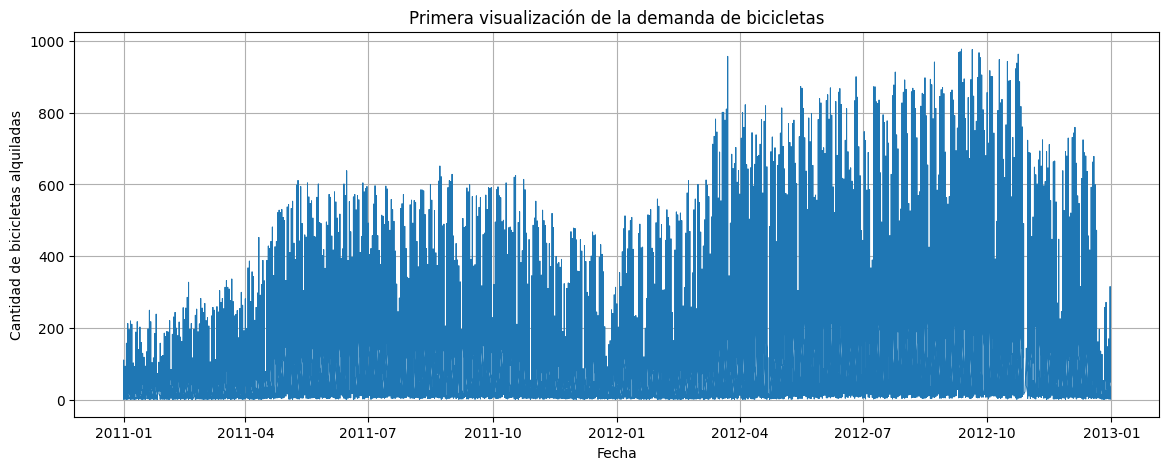

In [ ]:
# Usamos dteday como referencia temporal inicial solo para graficar
fechas = pd.to_datetime(datos["dteday"])

plt.figure(figsize=(14, 5))
plt.plot(fechas, datos["cnt"], linewidth=0.7)

plt.title("Primera visualización de la demanda de bicicletas")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de bicicletas alquiladas")
plt.grid(True)
plt.show()

La primera visualización permite ver la evolución general de la demanda, pero también muestra una limitación importante: el dataset tiene registros horarios y, en esta gráfica inicial, usamos solo la fecha del día como referencia temporal.

Eso hace que varias observaciones de un mismo día aparezcan sobre la misma fecha, generando un gráfico muy denso y difícil de interpretar.

Para representar mejor la serie temporal, necesitamos construir una marca temporal completa que combine la fecha (`dteday`) con la hora (`hr`). Luego podremos volver a graficar la serie.

In [ ]:
# Creamos una columna temporal completa combinando la fecha y la hora
datos["fecha"] = pd.to_datetime(datos["dteday"]) + pd.to_timedelta(datos["hr"], unit="h")

# Verificamos que la fecha quedó como una columna más del dataset
datos[["dteday", "hr", "fecha", "cnt"]].head()

,dteday,hr,fecha,cnt
0,2011-01-01,0,2011-01-01 00:00:00,16
1,2011-01-01,1,2011-01-01 01:00:00,40
2,2011-01-01,2,2011-01-01 02:00:00,32
3,2011-01-01,3,2011-01-01 03:00:00,13
4,2011-01-01,4,2011-01-01 04:00:00,1


## Visualización usando fecha y hora

Ahora que construimos una columna temporal completa, volvemos a graficar la serie usando `fecha` como referencia.

A diferencia de la primera gráfica, ahora cada observación queda asociada a una fecha y hora específica. Esto representa mejor la estructura horaria del dataset, aunque todavía no hemos ordenado los datos ni definido un índice temporal.

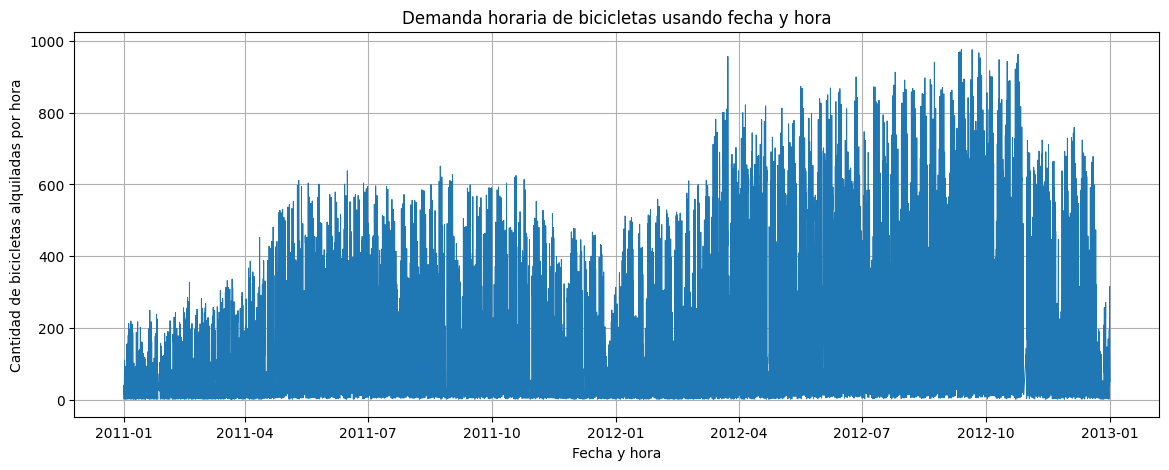

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(datos["fecha"], datos["cnt"], linewidth=0.7)

plt.title("Demanda horaria de bicicletas usando fecha y hora")
plt.xlabel("Fecha y hora")
plt.ylabel("Cantidad de bicicletas alquiladas por hora")
plt.grid(True)
plt.show()

## Vista diaria para mejorar la visualización

La serie original tiene registros horarios, por lo que el gráfico puede verse muy denso y difícil de interpretar.

Para observar mejor la evolución general de la demanda, vamos a construir una vista diaria solo con fines visuales. Para eso agrupamos los registros de cada día y sumamos la cantidad de bicicletas alquiladas.

Esta transformación no reemplaza al dataset original ni define todavía la resolución temporal de trabajo. Más adelante veremos formalmente el resampling y discutiremos cuándo conviene cambiar la frecuencia de una serie temporal.

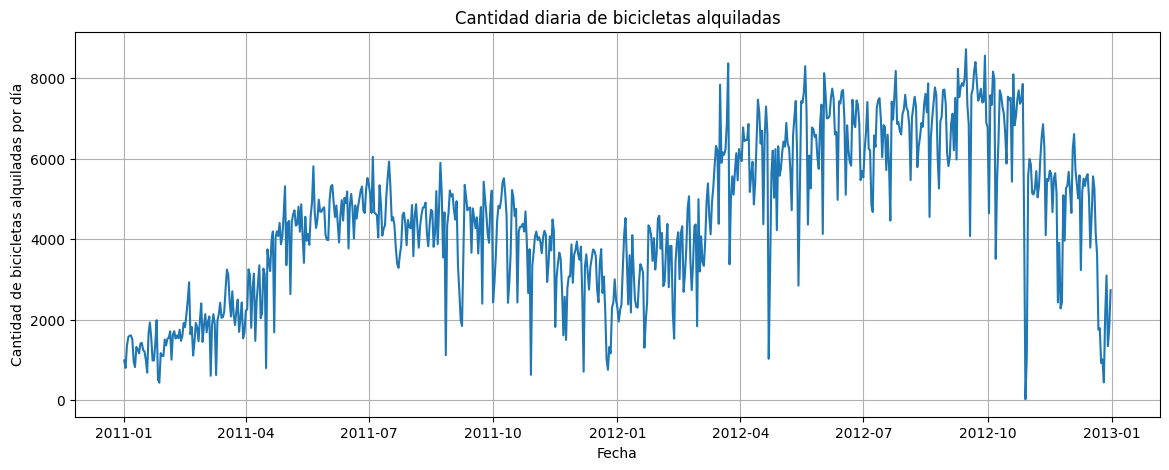

In [ ]:
# Creamos una vista diaria solo para visualizar mejor la serie
datos_diarios_vista = (
    datos
    .assign(dia=datos["fecha"].dt.date)
    .groupby("dia")["cnt"]
    .sum()
    .reset_index()
)

# Graficamos la cantidad total de bicicletas alquiladas por día
plt.figure(figsize=(14, 5))
plt.plot(datos_diarios_vista["dia"], datos_diarios_vista["cnt"])

plt.title("Cantidad diaria de bicicletas alquiladas")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de bicicletas alquiladas por día")
plt.grid(True)
plt.show()

## Ordenamiento cronológico de los datos

Una vez creada la columna `fecha`, podemos ordenar los registros según el momento en que ocurrieron.

Esto es importante porque en una serie temporal el orden de las observaciones debe respetar la secuencia real del tiempo.

En este paso todavía no vamos a definir `fecha` como índice temporal. Solo vamos a ordenar el dataset usando esa columna.

In [ ]:
# Ordenamos los registros cronológicamente usando la columna fecha
datos = datos.sort_values("fecha")

# Reiniciamos el índice numérico para que quede ordenado visualmente
datos = datos.reset_index(drop=True)

# Verificamos las primeras filas luego del ordenamiento
datos[["dteday", "hr", "fecha", "cnt"]].head()

,dteday,hr,fecha,cnt
0,2011-01-01,0,2011-01-01 00:00:00,16
1,2011-01-01,1,2011-01-01 01:00:00,40
2,2011-01-01,2,2011-01-01 02:00:00,32
3,2011-01-01,3,2011-01-01 03:00:00,13
4,2011-01-01,4,2011-01-01 04:00:00,1


In [ ]:
#Verificamos si quedó ordenado
datos["fecha"].is_monotonic_increasing

True

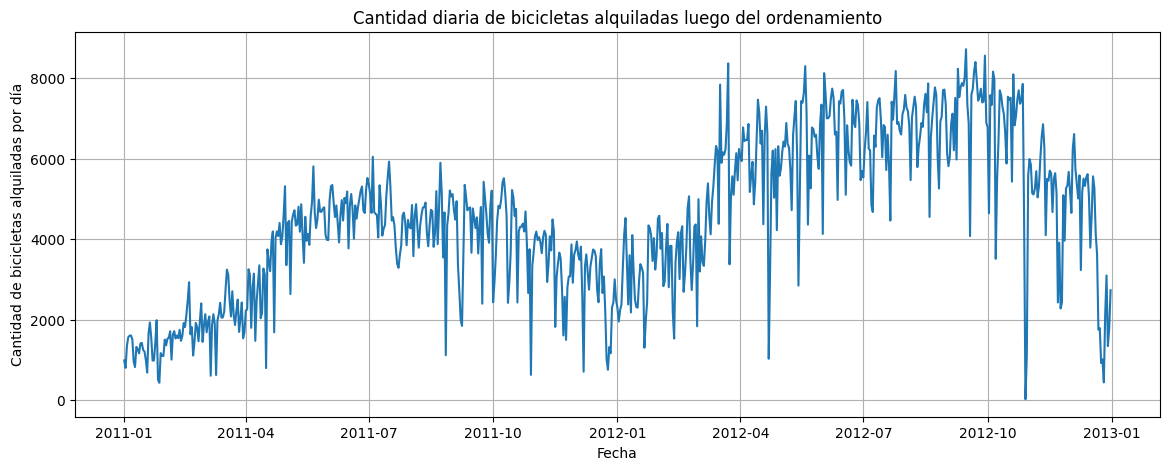

In [ ]:
# Creamos una vista diaria solo para visualizar mejor la serie luego del ordenamiento
datos_diarios_vista_ordenada = (
    datos
    .assign(dia=datos["fecha"].dt.floor("D"))
    .groupby("dia")["cnt"]
    .sum()
    .reset_index()
)

# Graficamos la cantidad total de bicicletas alquiladas por día
plt.figure(figsize=(14, 5))
plt.plot(datos_diarios_vista_ordenada["dia"], datos_diarios_vista_ordenada["cnt"])

plt.title("Cantidad diaria de bicicletas alquiladas luego del ordenamiento")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de bicicletas alquiladas por día")
plt.grid(True)
plt.show()

## Definición del índice temporal

Una vez que los registros están ordenados cronológicamente, vamos a usar la columna `fecha` como índice temporal del dataset.

Hasta ahora el DataFrame seguía teniendo un índice numérico automático. Al definir `fecha` como índice, cada fila queda identificada por el momento exacto en que ocurrió la observación.

Esto es importante porque, en una serie temporal, el índice no solo identifica filas: también representa el orden temporal de los datos.

In [ ]:
# Definimos la columna fecha como índice temporal
datos = datos.set_index("fecha")

# Verificamos cómo quedó el dataset
datos.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
fecha,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
2011-01-01 01:00:00,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2011-01-01 02:00:00,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
2011-01-01 03:00:00,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
2011-01-01 04:00:00,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
#Verificamos si el índice quedó ordenado
datos.index.is_monotonic_increasing

True

## Partición temporal inicial

Como el dataset ya está ordenado y tiene un índice temporal, podemos separar la serie respetando el orden del tiempo.

En esta primera partición usaremos los datos más antiguos como conjunto de entrenamiento y reservaremos el tramo final de la serie como conjunto de prueba.

Esta división no reemplaza a estrategias más completas de evaluación, como el backtesting o las ventanas temporales, que trabajaremos más adelante. Por ahora nos sirve para visualizar la idea central: entrenar con el pasado y evaluar sobre un período posterior.

In [ ]:
# Definimos el tamaño del conjunto de prueba
# En este caso reservamos el 20% final de la serie
n_test = int(len(datos) * 0.2)

# Partición temporal
train = datos.iloc[:-n_test].copy()
test = datos.iloc[-n_test:].copy()

# Verificamos los períodos obtenidos
print("Conjunto de entrenamiento:")
print(train.index.min(), "→", train.index.max())
print("Cantidad de registros:", len(train))

print("\nConjunto de prueba:")
print(test.index.min(), "→", test.index.max())
print("Cantidad de registros:", len(test))

Conjunto de entrenamiento:
2011-01-01 00:00:00 → 2012-08-07 12:00:00
Cantidad de registros: 13904

Conjunto de prueba:
2012-08-07 13:00:00 → 2012-12-31 23:00:00
Cantidad de registros: 3475


## Visualización de la partición temporal

Graficamos la serie completa diferenciando el conjunto de entrenamiento y el conjunto de prueba.

El tramo de entrenamiento corresponde a los datos más antiguos, mientras que el tramo de prueba queda al final de la serie, representando el período futuro reservado para evaluación.

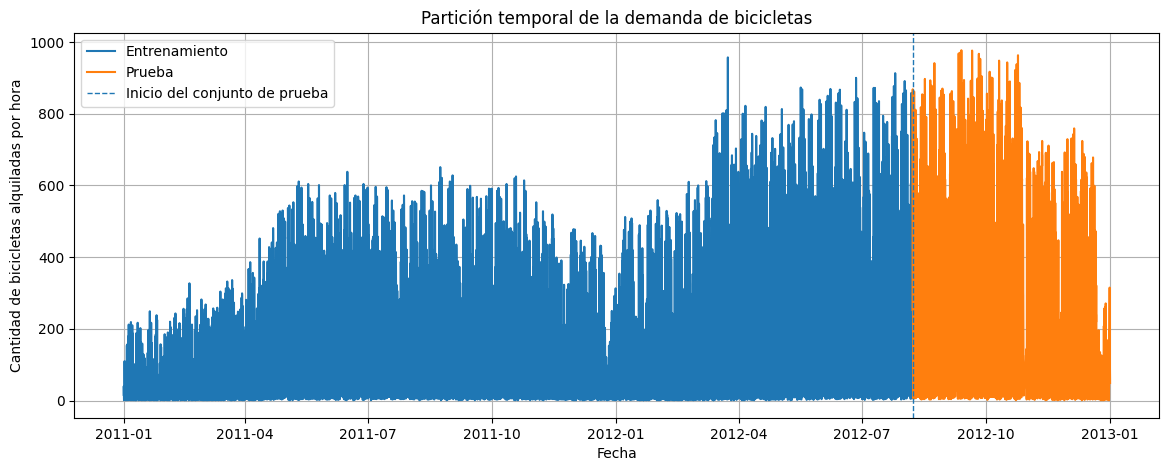

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(train.index, train["cnt"], label="Entrenamiento")
plt.plot(test.index, test["cnt"], label="Prueba")

plt.axvline(test.index.min(), linestyle="--", linewidth=1, label="Inicio del conjunto de prueba")

plt.title("Partición temporal de la demanda de bicicletas")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de bicicletas alquiladas por hora")
plt.legend()
plt.grid(True)
plt.show()

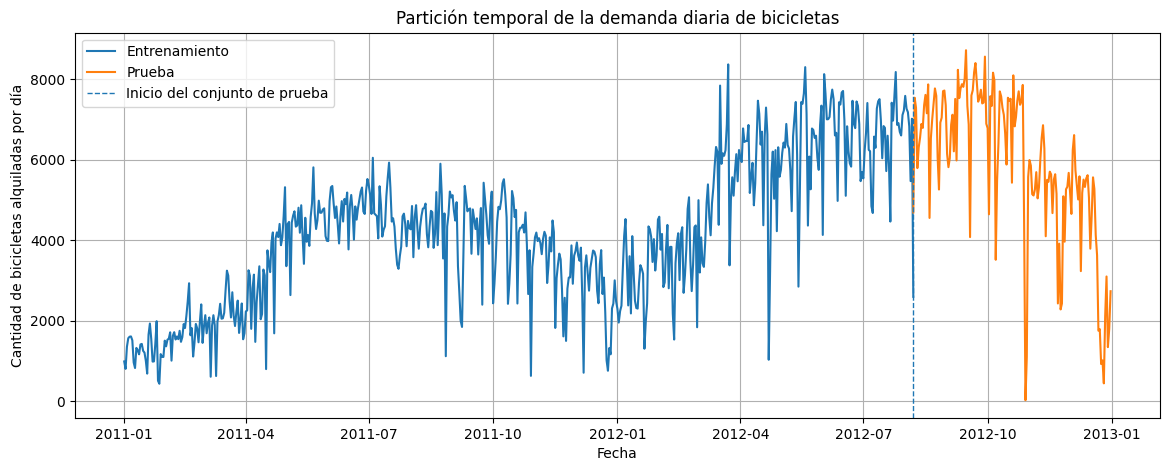

In [ ]:
# Creamos una vista diaria del conjunto de entrenamiento
train_diario_vista = (
    train
    .assign(dia=train.index.floor("D"))
    .groupby("dia")["cnt"]
    .sum()
    .reset_index()
)

# Creamos una vista diaria del conjunto de prueba
test_diario_vista = (
    test
    .assign(dia=test.index.floor("D"))
    .groupby("dia")["cnt"]
    .sum()
    .reset_index()
)

# Graficamos la partición temporal en vista diaria
plt.figure(figsize=(14, 5))

plt.plot(train_diario_vista["dia"], train_diario_vista["cnt"], label="Entrenamiento")
plt.plot(test_diario_vista["dia"], test_diario_vista["cnt"], label="Prueba")

plt.axvline(test_diario_vista["dia"].min(), linestyle="--", linewidth=1, label="Inicio del conjunto de prueba")

plt.title("Partición temporal de la demanda diaria de bicicletas")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de bicicletas alquiladas por día")
plt.legend()
plt.grid(True)
plt.show()

## Resampling diario de la serie

Hasta ahora trabajamos con el dataset en su frecuencia original: registros horarios.

Para simplificar el análisis y visualizar mejor la evolución general de la demanda, vamos a transformar la serie a una frecuencia diaria. Este proceso se conoce como `resampling`.

Al hacer resampling no todas las variables deben agregarse de la misma forma. La decisión depende del significado de cada columna:

- `cnt`: se suma, porque representa cantidad de bicicletas alquiladas por hora;
- `temp`, `atemp`, `hum` y `windspeed`: se promedian, porque son variables climáticas medidas durante el día;
- variables de calendario como `workingday`, `holiday`, `weekday`, `season`, `mnth` y `yr`: se conservan tomando un valor representativo del día;
- `weathersit`: se resume usando la categoría más frecuente del día.

Las columnas `casual` y `registered` no se usarán como predictoras, porque juntas componen directamente la variable objetivo `cnt`.

In [ ]:
# Aplicamos resampling diario definiendo una forma de agregación para cada variable
datos_diarios = datos.resample("D").agg({
    "cnt": "sum",
    "temp": "mean",
    "atemp": "mean",
    "hum": "mean",
    "windspeed": "mean",
    "workingday": "first",
    "holiday": "first",
    "weekday": "first",
    "season": "first",
    "mnth": "first",
    "yr": "first",
    "weathersit": lambda x: x.mode().iloc[0]
})

# Observamos el resultado
datos_diarios.head()

,cnt,temp,atemp,hum,windspeed,workingday,holiday,weekday,season,mnth,yr,weathersit
fecha,,,,,,,,,,,,
2011-01-01,985,0.344167,0.363625,0.805833,0.160446,0,0,6,1,1,0,1
2011-01-02,801,0.363478,0.353739,0.696087,0.248539,0,0,0,1,1,0,2
2011-01-03,1349,0.196364,0.189405,0.437273,0.248309,1,0,1,1,1,0,1
2011-01-04,1562,0.200000,0.212122,0.590435,0.160296,1,0,2,1,1,0,1
2011-01-05,1600,0.226957,0.229270,0.436957,0.186900,1,0,3,1,1,0,1


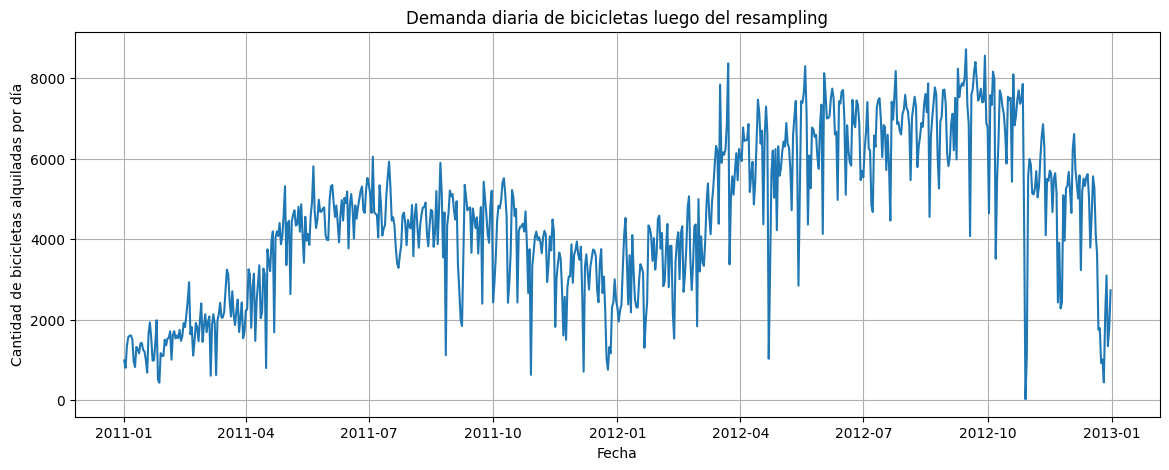

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(datos_diarios.index, datos_diarios["cnt"])

plt.title("Demanda diaria de bicicletas luego del resampling")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de bicicletas alquiladas por día")
plt.grid(True)
plt.show()

In [ ]:
datos_diarios.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2011-01-01 to 2012-12-31
Freq: D
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   cnt         731 non-null    int64  
 1   temp        731 non-null    float64
 2   atemp       731 non-null    float64
 3   hum         731 non-null    float64
 4   windspeed   731 non-null    float64
 5   workingday  731 non-null    int64  
 6   holiday     731 non-null    int64  
 7   weekday     731 non-null    int64  
 8   season      731 non-null    int64  
 9   mnth        731 non-null    int64  
 10  yr          731 non-null    int64  
 11  weathersit  731 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 74.2 KB


## Reinicio del flujo de trabajo

A partir de este punto vamos a retomar el trabajo desde el dataset horario preparado para la clase.

Hasta ahora usamos el dataset principalmente para introducir la idea de serie temporal, variable temporal, frecuencia, horizonte y resampling. Sin embargo, para trabajar la preparación de datos de forma más ordenada, vamos a comenzar nuevamente el flujo desde el archivo horario.

Desde aquí realizaremos el proceso completo paso a paso:

1. cargar el dataset;
2. construir la columna temporal;
3. ordenar los datos temporalmente;
4. revisar la frecuencia original;
5. detectar duplicados, huecos temporales y valores faltantes;
6. analizar cómo tratar los datos incompletos;
7. preparar la serie para el modelado;
8. realizar el resampling cuando corresponda.

La idea es mostrar que, antes de entrenar modelos de forecasting, es necesario comprender y preparar correctamente la estructura temporal de los datos.

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/01 -UTEC/01 -LIDIA/AA2/Unidad extra Series Temporales/Código/datos_horarios.csv")

In [ ]:
df.head()

,Unnamed: 0,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,0,1,2011-01-01,1.0,0,1,0,0,6,0,1.0,0.24,0.2879,0.81,0.0,3.0,13.0,16.0
1,1,2,2011-01-01,1.0,0,1,1,0,6,0,1.0,0.22,0.2727,0.80,0.0,8.0,32.0,40.0
2,2,3,2011-01-01,1.0,0,1,2,0,6,0,1.0,0.22,0.2727,0.80,0.0,5.0,27.0,32.0
3,3,4,2011-01-01,1.0,0,1,3,0,6,0,1.0,0.24,0.2879,0.75,0.0,3.0,10.0,13.0
4,4,5,2011-01-01,1.0,0,1,4,0,6,0,1.0,0.24,0.2879,0.75,0.0,0.0,1.0,1.0


In [ ]:
print(df.isnull().sum())

Unnamed: 0    0
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    7
temp          7
atemp         7
hum           7
windspeed     7
casual        7
registered    7
cnt           7
dtype: int64


## Construcción de la columna temporal

En este paso vamos a construir una columna temporal completa llamada `fecha`.

El dataset original tiene la fecha en la columna `dteday` y la hora del día en la columna `hr`.  
Para trabajar correctamente con una serie temporal horaria, necesitamos combinar ambas columnas en una única variable de tipo fecha y hora.

Luego vamos a:

1. ordenar los datos cronológicamente;
2. verificar que la columna temporal esté en orden creciente;
3. definir la columna `fecha` como índice temporal del DataFrame.

Esto es importante porque muchas operaciones de series temporales, como visualización, resampling, detección de huecos y modelado, requieren que los datos estén correctamente ordenados en el tiempo.

In [ ]:
# Creamos una columna temporal completa combinando la fecha y la hora.
# La columna "dteday" contiene el día y la columna "hr" contiene la hora del día.
df["fecha"] = pd.to_datetime(df["dteday"]) + pd.to_timedelta(df["hr"], unit="h")

# Mostramos las primeras filas para verificar que la columna "fecha" fue creada correctamente.
df.head()

,Unnamed: 0,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,fecha
0,0,1,2011-01-01,1.0,0,1,0,0,6,0,1.0,0.24,0.2879,0.81,0.0,3.0,13.0,16.0,2011-01-01 00:00:00
1,1,2,2011-01-01,1.0,0,1,1,0,6,0,1.0,0.22,0.2727,0.80,0.0,8.0,32.0,40.0,2011-01-01 01:00:00
2,2,3,2011-01-01,1.0,0,1,2,0,6,0,1.0,0.22,0.2727,0.80,0.0,5.0,27.0,32.0,2011-01-01 02:00:00
3,3,4,2011-01-01,1.0,0,1,3,0,6,0,1.0,0.24,0.2879,0.75,0.0,3.0,10.0,13.0,2011-01-01 03:00:00
4,4,5,2011-01-01,1.0,0,1,4,0,6,0,1.0,0.24,0.2879,0.75,0.0,0.0,1.0,1.0,2011-01-01 04:00:00


In [ ]:
# Ordenamos el DataFrame cronológicamente usando la columna "fecha".
# Esto asegura que las observaciones queden desde la más antigua hasta la más reciente.
df = df.sort_values("fecha")

# Mostramos las primeras filas luego del ordenamiento.
df.head()

,Unnamed: 0,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,fecha
0,0,1,2011-01-01,1.0,0,1,0,0,6,0,1.0,0.24,0.2879,0.81,0.0,3.0,13.0,16.0,2011-01-01 00:00:00
1,1,2,2011-01-01,1.0,0,1,1,0,6,0,1.0,0.22,0.2727,0.80,0.0,8.0,32.0,40.0,2011-01-01 01:00:00
2,2,3,2011-01-01,1.0,0,1,2,0,6,0,1.0,0.22,0.2727,0.80,0.0,5.0,27.0,32.0,2011-01-01 02:00:00
3,3,4,2011-01-01,1.0,0,1,3,0,6,0,1.0,0.24,0.2879,0.75,0.0,3.0,10.0,13.0,2011-01-01 03:00:00
4,4,5,2011-01-01,1.0,0,1,4,0,6,0,1.0,0.24,0.2879,0.75,0.0,0.0,1.0,1.0,2011-01-01 04:00:00


In [ ]:
# Verificamos si la columna "fecha" está ordenada de menor a mayor.
# El resultado debería ser True si el orden temporal es correcto.
df["fecha"].is_monotonic_increasing

True

In [ ]:
# Definimos la columna "fecha" como índice temporal del DataFrame.
# Esto permite trabajar con operaciones propias de series temporales.
# Con drop=True, la columna "fecha" deja de aparecer como columna común y queda solo como índice.
df = df.set_index("fecha", drop=True).sort_index()

# Mostramos las primeras filas para confirmar que "fecha" quedó como índice temporal.
df.head()

,Unnamed: 0,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
fecha,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,0,1,2011-01-01,1.0,0,1,0,0,6,0,1.0,0.24,0.2879,0.81,0.0,3.0,13.0,16.0
2011-01-01 01:00:00,1,2,2011-01-01,1.0,0,1,1,0,6,0,1.0,0.22,0.2727,0.80,0.0,8.0,32.0,40.0
2011-01-01 02:00:00,2,3,2011-01-01,1.0,0,1,2,0,6,0,1.0,0.22,0.2727,0.80,0.0,5.0,27.0,32.0
2011-01-01 03:00:00,3,4,2011-01-01,1.0,0,1,3,0,6,0,1.0,0.24,0.2879,0.75,0.0,3.0,10.0,13.0
2011-01-01 04:00:00,4,5,2011-01-01,1.0,0,1,4,0,6,0,1.0,0.24,0.2879,0.75,0.0,0.0,1.0,1.0


## Rango temporal y separación entre observaciones

Ahora que `fecha` quedó definida como índice temporal, vamos a revisar dos aspectos importantes de la serie:

1. **Rango temporal:** desde qué fecha y hora comienza la serie y hasta cuándo llega.
2. **Separación entre observaciones:** cada cuánto aparecen los registros consecutivos.

Esto nos permite verificar si la serie tiene una frecuencia regular, por ejemplo horaria, diaria, semanal, etc.

In [ ]:
# Revisamos desde cuándo hasta cuándo llega la serie temporal.
# Como "fecha" es el índice, usamos df.index.min() y df.index.max().
df.index.min(), df.index.max()

(Timestamp('2011-01-01 00:00:00'), Timestamp('2012-12-31 23:00:00'))

In [ ]:
# Calculamos la diferencia de tiempo entre cada observación y la anterior.
# Luego contamos cuántas veces aparece cada separación temporal.
df.index.to_series().diff().value_counts().head()

,count
fecha,
0 days 01:00:00,17543


## Verificación de huecos temporales

Una vez definido el índice temporal, podemos comprobar si la serie tiene horas faltantes.

Para eso vamos a construir un rango horario completo desde la primera fecha hasta la última fecha del dataset.  
Luego vamos a comparar ese rango completo contra el índice real de `df`.

Si existen fechas en el rango completo que no aparecen en el índice del dataset, significa que hay huecos temporales.

In [ ]:
# Construimos un rango horario completo desde la primera hasta la última fecha del dataset.
# La frecuencia "h" indica que queremos una observación por cada hora.
rango_completo = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="h"
)

# Comparamos el rango horario completo contra el índice real del DataFrame.
# Las fechas que están en rango_completo pero no están en df.index corresponden a huecos temporales.
fechas_faltantes = rango_completo.difference(df.index)

# Contamos cuántas fechas horarias faltan en la serie.
len(fechas_faltantes)

0

## Revisión de valores faltantes y duplicados temporales

Antes de seguir con el análisis o el modelado, vamos a revisar dos posibles problemas del dataset:

1. Valores faltantes en las columnas.
2. Fechas duplicadas en el índice temporal.

Los valores faltantes pueden afectar el análisis visual, el resampling y el entrenamiento de modelos.  
Los duplicados temporales también son importantes porque, en una serie horaria, normalmente esperamos tener una sola observación por cada fecha y hora.

In [ ]:
# Revisamos cuántos valores faltantes tiene cada columna del DataFrame.
# Esto nos permite identificar si hay variables con datos incompletos.
df.isna().sum()

,0
Unnamed: 0,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0


In [ ]:
# Calculamos el porcentaje de valores faltantes por columna.
# Multiplicamos por 100 para expresarlo como porcentaje.
# Ordenamos de mayor a menor para ver primero las columnas con más faltantes.
porcentaje_faltantes = (df.isna().mean() * 100).sort_values(ascending=False)

porcentaje_faltantes

,0
registered,0.0399
cnt,0.0399
hum,0.0399
atemp,0.0399
casual,0.0399
windspeed,0.0399
temp,0.0399
weathersit,0.0399
instant,0.0000
Unnamed: 0,0.0000


In [ ]:
# Si existieran fechas duplicadas, las mostramos para revisarlas.
# keep=False permite marcar todas las ocurrencias duplicadas, no solo una de ellas.
df[df.index.duplicated(keep=False)].head()

,Unnamed: 0,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
fecha,,,,,,,,,,,,,,,,,,


## Ejemplo visual de interpolación sobre un bloque de faltantes

Para ver claramente cómo actúa la interpolación, vamos a enfocarnos en un bloque de valores faltantes consecutivos.

En los siguientes gráficos:

- la **serie original observada** se muestra en **negro**;
- el **tramo completado por interpolación** se muestra en color;
- los **valores imputados** se destacan con puntos.

Se comparan dos métodos sobre la misma ventana temporal:

1. interpolación lineal;
2. interpolación cuadrática.

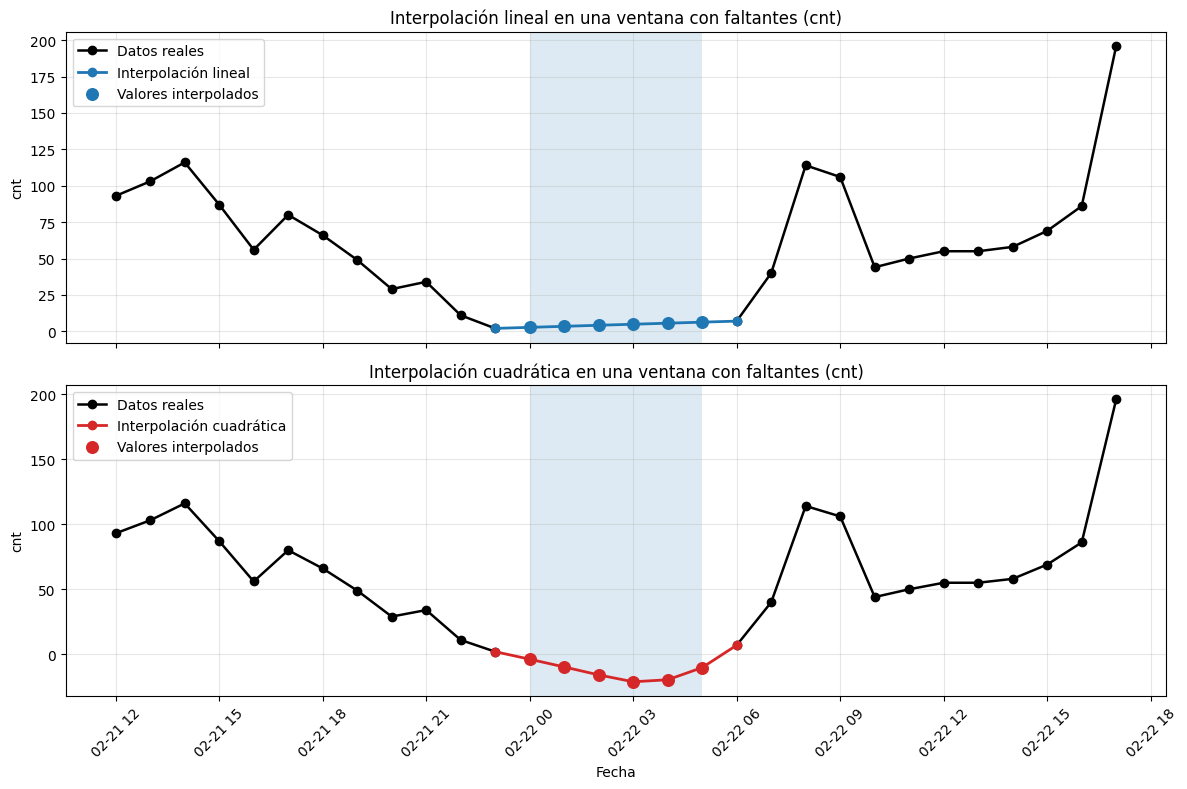

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Variable que vamos a usar en el ejemplo
variable_ejemplo = "cnt"

# Seleccionamos columnas numéricas
cols_interp = df.select_dtypes(include="number").columns

# Creamos copias interpoladas
df_lineal = df.copy()
df_lineal[cols_interp] = df_lineal[cols_interp].interpolate(method="linear")

df_cuadratica = df.copy()
df_cuadratica[cols_interp] = df_cuadratica[cols_interp].interpolate(method="quadratic")

# ---------------------------------------------------------
# 1. Buscar el primer bloque de al menos 6 NaN consecutivos
# ---------------------------------------------------------
nan_mask = df[variable_ejemplo].isna()
grupos = nan_mask.ne(nan_mask.shift()).cumsum()

resumen_bloques = pd.DataFrame({
    "es_nan": nan_mask.groupby(grupos).first(),
    "longitud": nan_mask.groupby(grupos).size()
})

bloque_id = resumen_bloques[
    (resumen_bloques["es_nan"] == True) & (resumen_bloques["longitud"] >= 6)
].index[0]

idx_bloque = df.index[grupos == bloque_id]
inicio_bloque = idx_bloque[0]
fin_bloque = idx_bloque[-1]

# ---------------------------------------------------------
# 2. Definir una ventana de zoom alrededor del bloque
# ---------------------------------------------------------
inicio_zoom = inicio_bloque - pd.Timedelta(hours=12)
fin_zoom = fin_bloque + pd.Timedelta(hours=12)

serie_original = df.loc[inicio_zoom:fin_zoom, variable_ejemplo]
serie_lineal = df_lineal.loc[inicio_zoom:fin_zoom, variable_ejemplo]
serie_cuadratica = df_cuadratica.loc[inicio_zoom:fin_zoom, variable_ejemplo]

# Índices del bloque faltante
idx_faltantes = idx_bloque

# Para dibujar solo el tramo interpolado, tomamos:
# un punto anterior + el bloque faltante + un punto posterior
pos_ini = df.index.get_loc(inicio_bloque)
pos_fin = df.index.get_loc(fin_bloque)

pos_ini_tramo = max(0, pos_ini - 1)
pos_fin_tramo = min(len(df) - 1, pos_fin + 1)

idx_tramo = df.index[pos_ini_tramo:pos_fin_tramo + 1]

# ---------------------------------------------------------
# 3. Graficar
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ----- Gráfico 1: interpolación lineal -----
axes[0].plot(
    serie_original.index,
    serie_original.values,
    color="black",
    marker="o",
    linewidth=1.8,
    label="Datos reales"
)

axes[0].plot(
    idx_tramo,
    df_lineal.loc[idx_tramo, variable_ejemplo],
    color="tab:blue",
    marker="o",
    linewidth=2,
    label="Interpolación lineal"
)

axes[0].scatter(
    idx_faltantes,
    df_lineal.loc[idx_faltantes, variable_ejemplo],
    color="tab:blue",
    s=70,
    zorder=3,
    label="Valores interpolados"
)

axes[0].axvspan(inicio_bloque, fin_bloque, alpha=0.15)
axes[0].set_title(f"Interpolación lineal en una ventana con faltantes ({variable_ejemplo})")
axes[0].set_ylabel(variable_ejemplo)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ----- Gráfico 2: interpolación cuadrática -----
axes[1].plot(
    serie_original.index,
    serie_original.values,
    color="black",
    marker="o",
    linewidth=1.8,
    label="Datos reales"
)

axes[1].plot(
    idx_tramo,
    df_cuadratica.loc[idx_tramo, variable_ejemplo],
    color="tab:red",
    marker="o",
    linewidth=2,
    label="Interpolación cuadrática"
)

axes[1].scatter(
    idx_faltantes,
    df_cuadratica.loc[idx_faltantes, variable_ejemplo],
    color="tab:red",
    s=70,
    zorder=3,
    label="Valores interpolados"
)

axes[1].axvspan(inicio_bloque, fin_bloque, alpha=0.15)
axes[1].set_title(f"Interpolación cuadrática en una ventana con faltantes ({variable_ejemplo})")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel(variable_ejemplo)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Comparación de `ffill` y `bfill` sobre la misma ventana

Además de interpolar, también es posible completar valores faltantes usando valores cercanos ya observados.

En esta tabla se comparan tres versiones de la misma ventana temporal:

- **original**: contiene los valores faltantes;
- **ffill**: completa usando el último valor conocido anterior;
- **bfill**: completa usando el siguiente valor conocido posterior.

Esto permite ver claramente cómo cambia la serie según el método utilizado.

In [ ]:
# Creamos las versiones con forward fill y backward fill.
df_ffill = df.ffill()
df_bfill = df.bfill()

# Construimos una tabla comparativa usando la misma ventana temporal
# que se utilizó en los gráficos de interpolación.
comparacion_ffill_bfill = pd.DataFrame({
    "original": df.loc[inicio_zoom:fin_zoom, variable_ejemplo],
    "ffill": df_ffill.loc[inicio_zoom:fin_zoom, variable_ejemplo],
    "bfill": df_bfill.loc[inicio_zoom:fin_zoom, variable_ejemplo]
})

# Mostramos solamente una parte de la ventana, centrada en el bloque faltante,
# para que se vea con claridad el antes y el después.
comparacion_ffill_bfill.loc[inicio_bloque - pd.Timedelta(hours=3): fin_bloque + pd.Timedelta(hours=3)]

,original,ffill,bfill
fecha,,,
2011-02-21 21:00:00,34.0,34.0,34.0
2011-02-21 22:00:00,11.0,11.0,11.0
2011-02-21 23:00:00,2.0,2.0,2.0
2011-02-22 00:00:00,NaN,2.0,7.0
2011-02-22 01:00:00,NaN,2.0,7.0
2011-02-22 02:00:00,NaN,2.0,7.0
2011-02-22 03:00:00,NaN,2.0,7.0
2011-02-22 04:00:00,NaN,2.0,7.0
2011-02-22 05:00:00,NaN,2.0,7.0


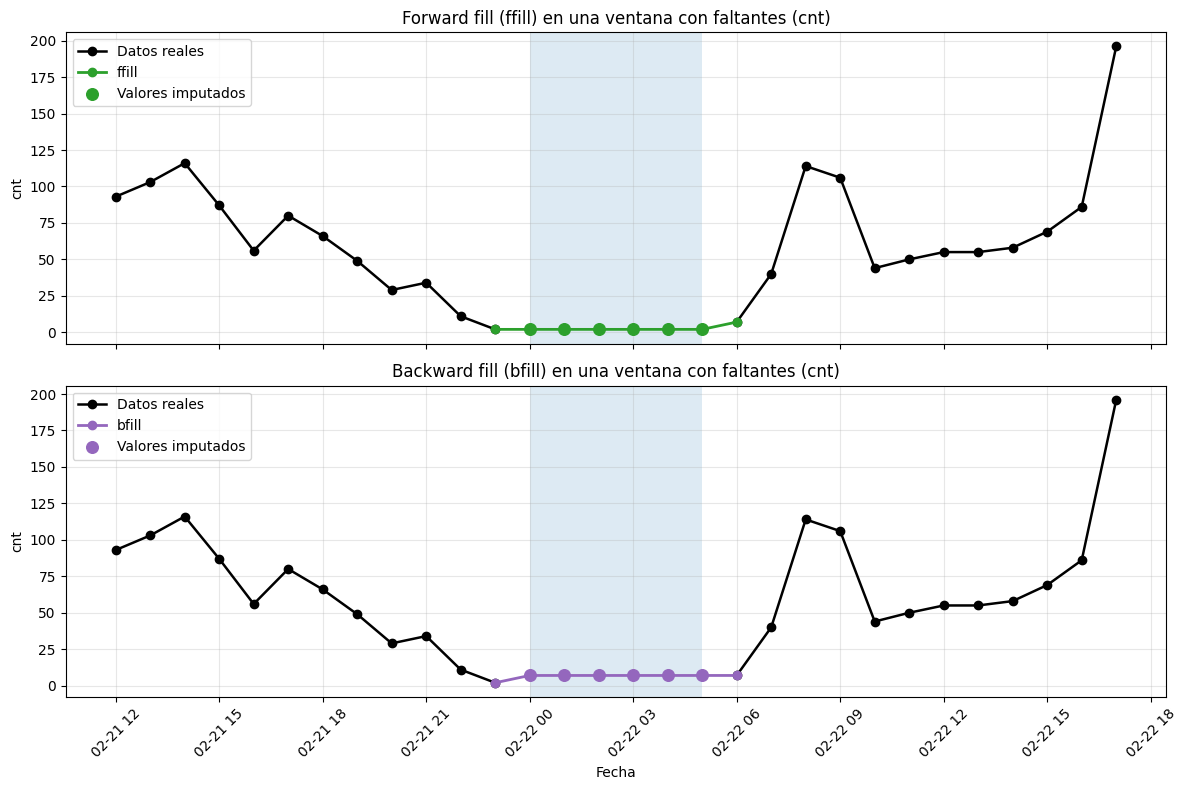

In [ ]:
# Creamos las versiones con forward fill y backward fill.
df_ffill = df.ffill()
df_bfill = df.bfill()

# Extraemos la misma ventana temporal usada en los gráficos anteriores.
serie_original = df.loc[inicio_zoom:fin_zoom, variable_ejemplo]
serie_ffill = df_ffill.loc[inicio_zoom:fin_zoom, variable_ejemplo]
serie_bfill = df_bfill.loc[inicio_zoom:fin_zoom, variable_ejemplo]

# Para dibujar solo el tramo completado, tomamos:
# un punto anterior + el bloque faltante + un punto posterior
pos_ini = df.index.get_loc(inicio_bloque)
pos_fin = df.index.get_loc(fin_bloque)

pos_ini_tramo = max(0, pos_ini - 1)
pos_fin_tramo = min(len(df) - 1, pos_fin + 1)

idx_tramo = df.index[pos_ini_tramo:pos_fin_tramo + 1]

# Generamos los dos gráficos.
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ----- Gráfico 1: ffill -----
axes[0].plot(
    serie_original.index,
    serie_original.values,
    color="black",
    marker="o",
    linewidth=1.8,
    label="Datos reales"
)

axes[0].plot(
    idx_tramo,
    df_ffill.loc[idx_tramo, variable_ejemplo],
    color="tab:green",
    marker="o",
    linewidth=2,
    label="ffill"
)

axes[0].scatter(
    idx_faltantes,
    df_ffill.loc[idx_faltantes, variable_ejemplo],
    color="tab:green",
    s=70,
    zorder=3,
    label="Valores imputados"
)

axes[0].axvspan(inicio_bloque, fin_bloque, alpha=0.15)
axes[0].set_title(f"Forward fill (ffill) en una ventana con faltantes ({variable_ejemplo})")
axes[0].set_ylabel(variable_ejemplo)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ----- Gráfico 2: bfill -----
axes[1].plot(
    serie_original.index,
    serie_original.values,
    color="black",
    marker="o",
    linewidth=1.8,
    label="Datos reales"
)

axes[1].plot(
    idx_tramo,
    df_bfill.loc[idx_tramo, variable_ejemplo],
    color="tab:purple",
    marker="o",
    linewidth=2,
    label="bfill"
)

axes[1].scatter(
    idx_faltantes,
    df_bfill.loc[idx_faltantes, variable_ejemplo],
    color="tab:purple",
    s=70,
    zorder=3,
    label="Valores imputados"
)

axes[1].axvspan(inicio_bloque, fin_bloque, alpha=0.15)
axes[1].set_title(f"Backward fill (bfill) en una ventana con faltantes ({variable_ejemplo})")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel(variable_ejemplo)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Tratamiento seleccionado para la variable objetivo

Después de comparar distintos métodos de imputación, vamos a seleccionar la interpolación lineal para completar los valores faltantes de la variable `cnt`.

Esta decisión se justifica porque:

- `cnt` representa una cantidad de bicicletas alquiladas, por lo que no debería tomar valores negativos;
- la interpolación cuadrática puede generar valores negativos en algunos tramos;
- `ffill` y `bfill` repiten valores observados, lo que puede producir segmentos poco realistas;
- la interpolación lineal completa los huecos internos conectando el valor anterior y el valor posterior de forma simple y controlada.

A partir de este punto, continuaremos trabajando con una versión del DataFrame en la que los faltantes de `cnt` fueron completados mediante interpolación lineal.

In [ ]:
# Creamos una copia del DataFrame original para aplicar el tratamiento seleccionado.
df_tratado = df.copy()

# Definimos la variable objetivo.
variable_objetivo = "cnt"

# Aplicamos interpolación lineal sobre la variable objetivo.
df_tratado[variable_objetivo] = df_tratado[variable_objetivo].interpolate(
    method="linear",
    limit_area="inside"
)

# Como cnt representa una cantidad de bicicletas alquiladas,
# redondeamos los valores interpolados y evitamos posibles valores negativos.
df_tratado[variable_objetivo] = (
    df_tratado[variable_objetivo]
    .round()
    .clip(lower=0)
    .astype("int64")
)

# Verificamos el resultado.
print("Faltantes en cnt antes del tratamiento:", df[variable_objetivo].isna().sum())
print("Faltantes en cnt después del tratamiento:", df_tratado[variable_objetivo].isna().sum())
print("Valor mínimo de cnt después del tratamiento:", df_tratado[variable_objetivo].min())

df_tratado.head()

Faltantes en cnt antes del tratamiento: 7
Faltantes en cnt después del tratamiento: 0
Valor mínimo de cnt después del tratamiento: 1


,Unnamed: 0,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
fecha,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,0,1,2011-01-01,1.0,0,1,0,0,6,0,1.0,0.24,0.2879,0.81,0.0,3.0,13.0,16
2011-01-01 01:00:00,1,2,2011-01-01,1.0,0,1,1,0,6,0,1.0,0.22,0.2727,0.80,0.0,8.0,32.0,40
2011-01-01 02:00:00,2,3,2011-01-01,1.0,0,1,2,0,6,0,1.0,0.22,0.2727,0.80,0.0,5.0,27.0,32
2011-01-01 03:00:00,3,4,2011-01-01,1.0,0,1,3,0,6,0,1.0,0.24,0.2879,0.75,0.0,3.0,10.0,13
2011-01-01 04:00:00,4,5,2011-01-01,1.0,0,1,4,0,6,0,1.0,0.24,0.2879,0.75,0.0,0.0,1.0,1


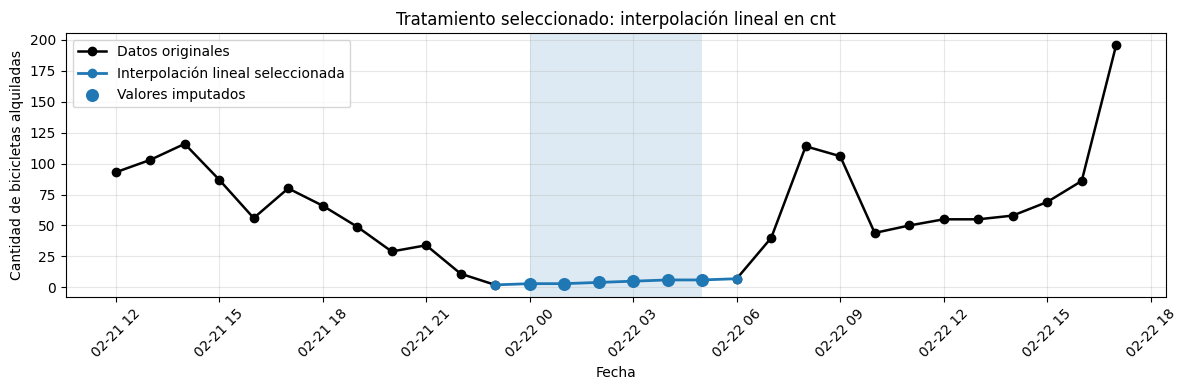

In [ ]:
# Graficamos el resultado final sobre la misma ventana usada en los ejemplos anteriores.
plt.figure(figsize=(12, 4))

# Datos reales observados.
plt.plot(
    df.loc[inicio_zoom:fin_zoom].index,
    df.loc[inicio_zoom:fin_zoom, variable_objetivo],
    color="black",
    marker="o",
    linewidth=1.8,
    label="Datos originales"
)

# Tramo interpolado linealmente.
plt.plot(
    idx_tramo,
    df_tratado.loc[idx_tramo, variable_objetivo],
    color="tab:blue",
    marker="o",
    linewidth=2,
    label="Interpolación lineal seleccionada"
)

# Valores imputados.
plt.scatter(
    idx_bloque,
    df_tratado.loc[idx_bloque, variable_objetivo],
    color="tab:blue",
    s=70,
    zorder=3,
    label="Valores imputados"
)

plt.axvspan(inicio_bloque, fin_bloque, alpha=0.15)

plt.title("Tratamiento seleccionado: interpolación lineal en cnt")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de bicicletas alquiladas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# A partir de este punto continuamos el análisis con el DataFrame tratado.
df = df_tratado.copy()

# Verificamos el estado final del DataFrame.
df.head()

,Unnamed: 0,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
fecha,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,0,1,2011-01-01,1.0,0,1,0,0,6,0,1.0,0.24,0.2879,0.81,0.0,3.0,13.0,16
2011-01-01 01:00:00,1,2,2011-01-01,1.0,0,1,1,0,6,0,1.0,0.22,0.2727,0.80,0.0,8.0,32.0,40
2011-01-01 02:00:00,2,3,2011-01-01,1.0,0,1,2,0,6,0,1.0,0.22,0.2727,0.80,0.0,5.0,27.0,32
2011-01-01 03:00:00,3,4,2011-01-01,1.0,0,1,3,0,6,0,1.0,0.24,0.2879,0.75,0.0,3.0,10.0,13
2011-01-01 04:00:00,4,5,2011-01-01,1.0,0,1,4,0,6,0,1.0,0.24,0.2879,0.75,0.0,0.0,1.0,1


## Resampling diario del dataset

Ahora vamos a cambiar la resolución temporal del dataset.

El dataset original tiene registros horarios. Para simplificar el análisis y trabajar con una serie diaria, vamos a agrupar las observaciones por día.

No todas las variables deben agregarse de la misma forma:

- `cnt` representa cantidad de bicicletas alquiladas, por eso se suma por día;
- `temp`, `atemp`, `hum` y `windspeed` son variables meteorológicas, por eso se promedian;
- `holiday` y `workingday` se resumen tomando el valor máximo del día;
- `weathersit` se resume tomando el valor máximo, interpretándolo como la peor condición climática registrada ese día.

En este paso también dejamos fuera columnas que ya no necesitamos para el análisis, como identificadores, columnas usadas para construir la fecha y las variables `casual` y `registered`, porque su suma forma la variable objetivo `cnt`.

In [ ]:
# Revisamos la forma del DataFrame horario antes del resampling.
forma_horaria = df.shape

# Eliminamos columnas que no vamos a usar en el análisis diario.
# errors="ignore" evita errores si alguna columna no existe en el DataFrame.
columnas_a_eliminar = [
    "instant",
    "dteday",
    "hr",
    "casual",
    "registered",
    "Unnamed: 0"
]

df_resampling = df.drop(columns=columnas_a_eliminar, errors="ignore")

# Aplicamos resampling diario usando una agregación adecuada para cada tipo de variable.
df_diario = df_resampling.resample("D").agg({
    "cnt": "sum",
    "temp": "mean",
    "atemp": "mean",
    "hum": "mean",
    "windspeed": "mean",
    "holiday": "max",
    "workingday": "max",
    "weathersit": "max"
})

# Revisamos cómo cambió la cantidad de registros.
print("Forma del dataset horario:", forma_horaria)
print("Forma del dataset diario:", df_diario.shape)

# Mostramos las primeras filas del nuevo DataFrame diario.
df_diario.head()

Forma del dataset horario: (17544, 18)
Forma del dataset diario: (731, 8)


,cnt,temp,atemp,hum,windspeed,holiday,workingday,weathersit
fecha,,,,,,,,
2011-01-01,985,0.344167,0.363625,0.805833,0.160446,0,0,3.0
2011-01-02,803,0.363478,0.353739,0.696087,0.248539,0,0,3.0
2011-01-03,1352,0.195000,0.186250,0.438750,0.261200,0,1,1.0
2011-01-04,1564,0.197500,0.210227,0.592083,0.158281,0,1,2.0
2011-01-05,1602,0.225833,0.228556,0.444167,0.185644,0,1,1.0


## Recuperación de variables calendario existentes

Después del resampling diario, algunas variables calendario del dataset original pueden haber quedado fuera del nuevo DataFrame.

En este caso no vamos a crear variables nuevas, sino recuperar variables que ya existían en el dataset horario y que no fueron incorporadas durante el resampling, como `yr`, `mnth` y `weekday`.

No recuperamos `holiday` ni `workingday`, porque esas variables ya fueron agregadas durante el resampling diario.
Para hacerlo, tomamos esas columnas desde el DataFrame original `df`, las agrupamos por día y luego las incorporamos al DataFrame diario `df_diario`.

No modificamos el resampling anterior; simplemente recuperamos información calendario que ya estaba presente en el dataset.

In [ ]:
# Definimos las variables calendario que ya existían en el dataset original
# y que podrían ser útiles en el dataset diario.
columnas_calendario = ["yr", "mnth", "weekday"]

# Nos quedamos solamente con las columnas que existen en df
# y que todavía no están presentes en df_diario.
columnas_a_recuperar = [
    col for col in columnas_calendario
    if col in df.columns and col not in df_diario.columns
]

# Definimos cómo recuperar cada variable al pasar de datos horarios a diarios.
# Para yr, mnth y weekday tomamos el primer valor del día,
# porque deberían ser constantes dentro de cada día.

agregaciones_calendario = {
    "yr": "first",
    "mnth": "first",
    "weekday": "first",
}

# Recuperamos solamente las columnas necesarias.
variables_recuperadas = df[columnas_a_recuperar].resample("D").agg({
    col: agregaciones_calendario[col]
    for col in columnas_a_recuperar
})

# Incorporamos esas variables al dataset diario.
df_diario = df_diario.join(variables_recuperadas)

# Mostramos las primeras filas para verificar el resultado.
df_diario.head()

,cnt,temp,atemp,hum,windspeed,holiday,workingday,weathersit,yr,mnth,weekday
fecha,,,,,,,,,,,
2011-01-01,985,0.344167,0.363625,0.805833,0.160446,0,0,3.0,0,1,6
2011-01-02,803,0.363478,0.353739,0.696087,0.248539,0,0,3.0,0,1,0
2011-01-03,1352,0.195000,0.186250,0.438750,0.261200,0,1,1.0,0,1,1
2011-01-04,1564,0.197500,0.210227,0.592083,0.158281,0,1,2.0,0,1,2
2011-01-05,1602,0.225833,0.228556,0.444167,0.185644,0,1,1.0,0,1,3


## Visualización de la demanda diaria

Una vez realizado el resampling diario, podemos visualizar la variable objetivo `cnt`.

En este caso, `cnt` representa la cantidad total de bicicletas alquiladas por día.  
El gráfico nos permite observar la evolución general de la demanda, posibles patrones, períodos de mayor o menor uso y cambios a lo largo del tiempo.

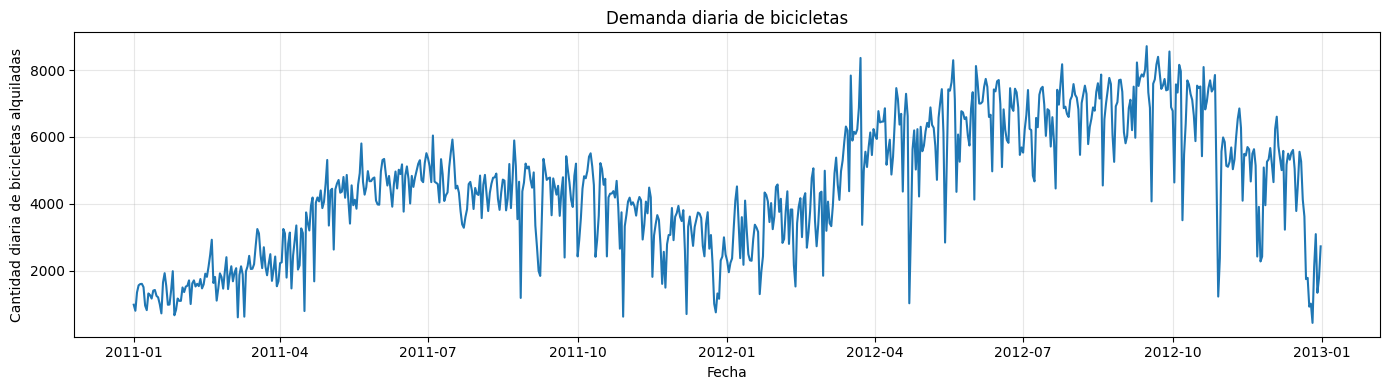

In [ ]:
# Graficamos la variable objetivo diaria.
# En este caso, "cnt" representa la cantidad total de bicicletas alquiladas por día.
plt.figure(figsize=(14, 4))

plt.plot(df_diario.index, df_diario["cnt"])

plt.title("Demanda diaria de bicicletas")
plt.xlabel("Fecha")
plt.ylabel("Cantidad diaria de bicicletas alquiladas")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Tendencia lineal y media móvil

La media móvil permite suavizar la serie y observar mejor su evolución local.

La tendencia lineal, en cambio, resume el comportamiento general de toda la serie mediante una recta.  
Esto permite ver si, globalmente, la demanda tiende a aumentar, disminuir o mantenerse estable.

En el siguiente gráfico comparamos:

- la demanda diaria original;
- la media móvil de 7 días;
- una tendencia lineal ajustada sobre toda la serie.

In [ ]:
# Calculamos la media móvil de 7 días.
df_diario["media_movil_7"] = df_diario["cnt"].rolling(window=7).mean()

# Creamos una variable numérica que representa el paso del tiempo.
# Cada día recibe un número consecutivo: 0, 1, 2, 3, ...
tiempo = np.arange(len(df_diario))

# Ajustamos una recta de tendencia sobre la variable objetivo.
# polyfit con grado 1 ajusta una función lineal: y = a*x + b.
coeficientes = np.polyfit(tiempo, df_diario["cnt"], deg=1)

# Calculamos los valores de la tendencia lineal para cada día.
df_diario["tendencia_lineal"] = np.polyval(coeficientes, tiempo)

# Mostramos las primeras filas para verificar las nuevas columnas.
df_diario.head(10)

,cnt,temp,atemp,hum,windspeed,holiday,workingday,weathersit,yr,mnth,weekday,media_movil_7,tendencia_lineal
fecha,,,,,,,,,,,,,
2011-01-01,985,0.344167,0.363625,0.805833,0.160446,0,0,3.0,0,1,6,NaN,2398.256173
2011-01-02,803,0.363478,0.353739,0.696087,0.248539,0,0,3.0,0,1,0,NaN,2404.039756
2011-01-03,1352,0.195000,0.186250,0.438750,0.261200,0,1,1.0,0,1,1,NaN,2409.823339
2011-01-04,1564,0.197500,0.210227,0.592083,0.158281,0,1,2.0,0,1,2,NaN,2415.606922
2011-01-05,1602,0.225833,0.228556,0.444167,0.185644,0,1,1.0,0,1,3,NaN,2421.390505
2011-01-06,1608,0.202500,0.232331,0.523333,0.087700,0,1,2.0,0,1,4,NaN,2427.174089
2011-01-07,1511,0.196667,0.208660,0.506667,0.169158,0,1,3.0,0,1,5,1346.428571,2432.957672
2011-01-08,959,0.165000,0.162254,0.535833,0.266804,0,0,3.0,0,1,6,1342.714286,2438.741255
2011-01-09,822,0.138333,0.116175,0.434167,0.361950,0,0,1.0,0,1,0,1345.428571,2444.524838


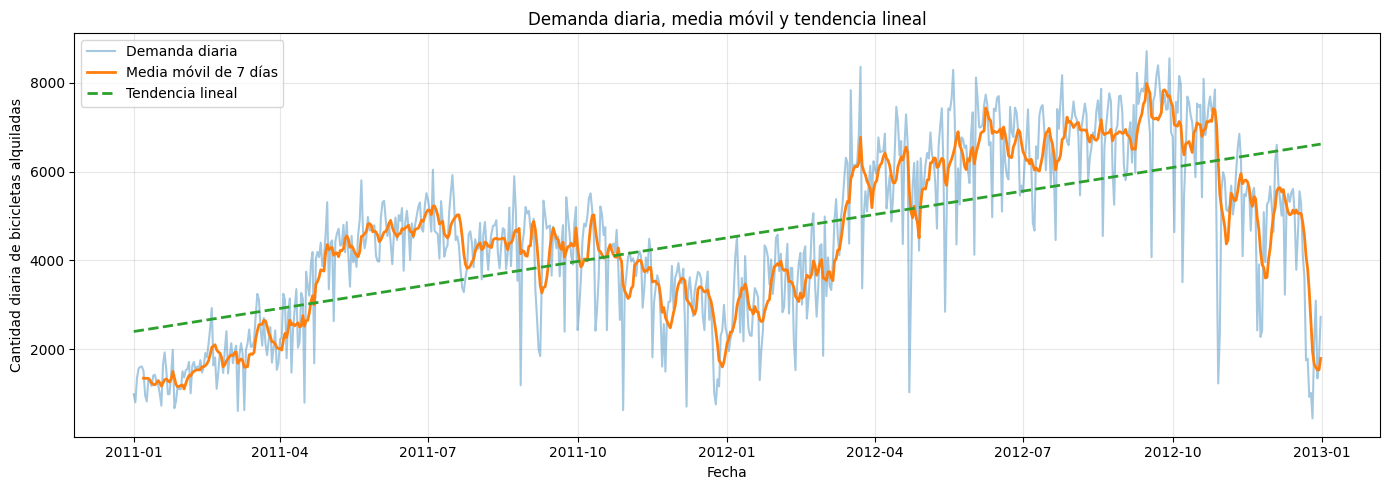

In [ ]:
# Graficamos la demanda diaria, la media móvil y la tendencia lineal.
plt.figure(figsize=(14, 5))

plt.plot(
    df_diario.index,
    df_diario["cnt"],
    label="Demanda diaria",
    alpha=0.4
)

plt.plot(
    df_diario.index,
    df_diario["media_movil_7"],
    label="Media móvil de 7 días",
    linewidth=2
)

plt.plot(
    df_diario.index,
    df_diario["tendencia_lineal"],
    label="Tendencia lineal",
    linewidth=2,
    linestyle="--"
)

plt.title("Demanda diaria, media móvil y tendencia lineal")
plt.xlabel("Fecha")
plt.ylabel("Cantidad diaria de bicicletas alquiladas")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Descomposición aditiva de la serie diaria

Ahora vamos a realizar una descomposición simple de la serie temporal diaria.

La descomposición permite separar visualmente la serie en tres componentes:

- **tendencia:** evolución general de largo plazo;
- **estacionalidad:** patrón que se repite cada cierto período;
- **residuo:** variaciones que no son explicadas por la tendencia ni por la estacionalidad.

En este ejemplo usamos `period=7` como una primera aproximación para explorar una posible estacionalidad semanal en la demanda diaria de bicicletas.

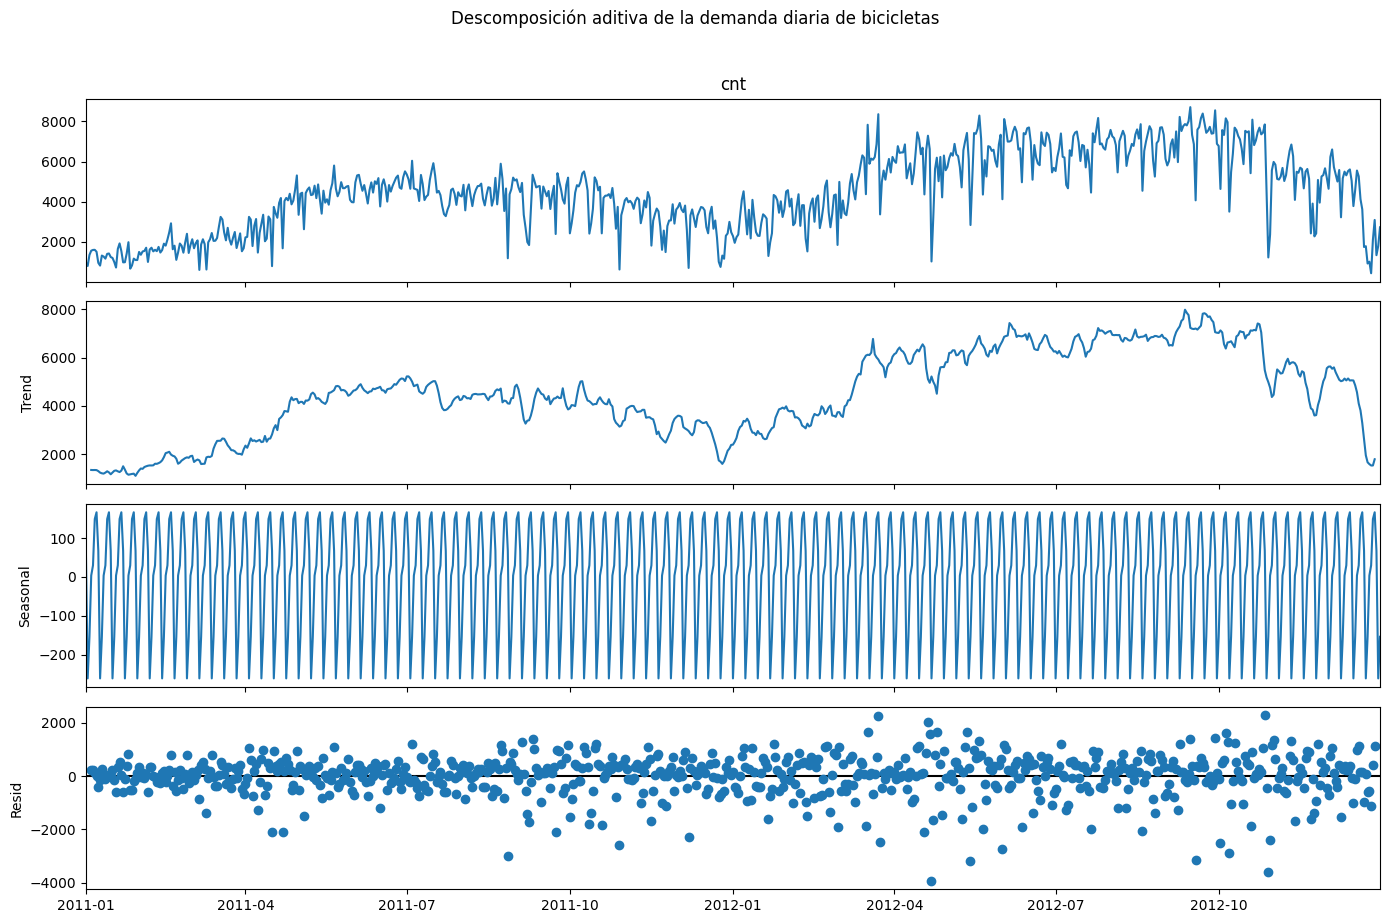

In [ ]:
# Importamos la función para descomponer series temporales.
from statsmodels.tsa.seasonal import seasonal_decompose

# Aplicamos una descomposición aditiva sobre la variable objetivo diaria.
# Usamos dropna() porque la función no admite valores faltantes.
# period=7 indica que exploramos un posible patrón semanal.
descomposicion = seasonal_decompose(
    df_diario["cnt"].dropna(),
    model="additive",
    period=7
)

# Graficamos la serie observada, la tendencia, la estacionalidad y el residuo.
fig = descomposicion.plot()

# Aumentamos el tamaño general de la figura.
fig.set_size_inches(14, 9)

# Agregamos un título general.
fig.suptitle(
    "Descomposición aditiva de la demanda diaria de bicicletas",
    y=1.02
)

plt.tight_layout()
plt.show()

## Patrones por día de semana y por mes

Ahora vamos a analizar si la demanda diaria de bicicletas presenta patrones asociados al calendario.

Este análisis es solamente exploratorio: no modifica el DataFrame `df_diario`.

Vamos a calcular:

- la demanda promedio por día de semana;
- la demanda promedio por mes.

Estos gráficos ayudan a observar posibles patrones repetidos, diferencias entre días laborales y fines de semana, o variaciones estacionales a lo largo del año.

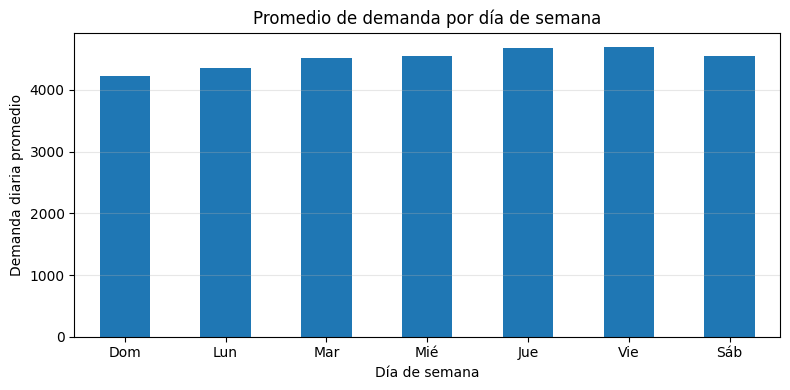

In [ ]:
# Definimos nombres para mejorar la lectura de los días de semana.
# En el dataset Bike Sharing, weekday usa 0 = domingo y 6 = sábado.
nombres_dias = {
    0: "Dom",
    1: "Lun",
    2: "Mar",
    3: "Mié",
    4: "Jue",
    5: "Vie",
    6: "Sáb"
}

# Calculamos el promedio de demanda diaria por día de semana.
# Esto no modifica df_diario; solo crea una serie temporal auxiliar para graficar.
promedio_dia = df_diario.groupby("weekday")["cnt"].mean()

# Reemplazamos los números del índice por nombres de días para mejorar la visualización.
promedio_dia.index = promedio_dia.index.map(nombres_dias)

# Graficamos el promedio de demanda por día de semana.
plt.figure(figsize=(8, 4))
promedio_dia.plot(kind="bar")

plt.title("Promedio de demanda por día de semana")
plt.xlabel("Día de semana")
plt.ylabel("Demanda diaria promedio")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

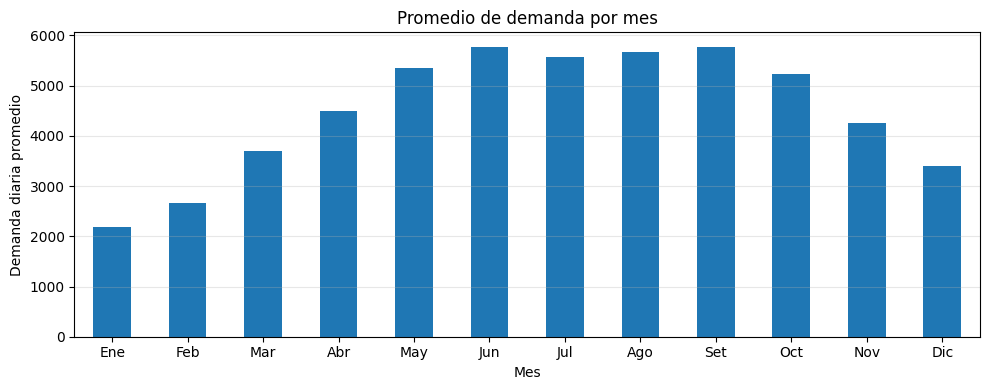

In [ ]:
# Definimos nombres de meses para mejorar la lectura del gráfico.
nombres_meses = {
    1: "Ene",
    2: "Feb",
    3: "Mar",
    4: "Abr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Set",
    10: "Oct",
    11: "Nov",
    12: "Dic"
}

# Calculamos el promedio de demanda diaria por mes.
# Nuevamente, esto es solo para análisis visual y no modifica df_diario.
promedio_mes = df_diario.groupby("mnth")["cnt"].mean()

# Reemplazamos los números del índice por nombres de meses.
promedio_mes.index = promedio_mes.index.map(nombres_meses)

# Graficamos el promedio de demanda por mes.
plt.figure(figsize=(10, 4))
promedio_mes.plot(kind="bar")

plt.title("Promedio de demanda por mes")
plt.xlabel("Mes")
plt.ylabel("Demanda diaria promedio")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Ruido, variabilidad y valores llamativos

Ahora vamos a revisar la distribución de la demanda diaria de bicicletas.

Este análisis es exploratorio y no modifica el DataFrame.  
Nos ayuda a observar la variabilidad de la variable objetivo `cnt`, identificar valores altos o bajos poco frecuentes y decidir si conviene analizarlos con más detalle.

Un valor llamativo no necesariamente es un error: puede corresponder a un evento real, un feriado, mal clima, una temporada particular o cambios en el uso del servicio.

In [ ]:
# Calculamos un resumen estadístico de la variable objetivo diaria.
# Esto nos permite ver cantidad de datos, media, desvío estándar,
# valores mínimos, máximos y cuartiles.
df_diario["cnt"].describe()

,cnt
count,731.000000
mean,4509.264022
std,1929.052762
min,441.000000
25%,3152.000000
50%,4548.000000
75%,5958.000000
max,8714.000000


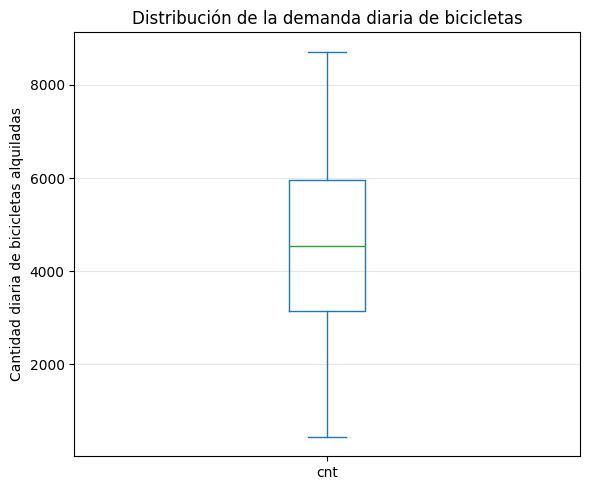

In [ ]:
# Mostramos un boxplot para analizar la distribución de la demanda diaria.
# Este gráfico permite identificar la mediana, la dispersión y posibles valores atípicos.
plt.figure(figsize=(6, 5))

df_diario["cnt"].plot.box()

plt.title("Distribución de la demanda diaria de bicicletas")
plt.ylabel("Cantidad diaria de bicicletas alquiladas")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

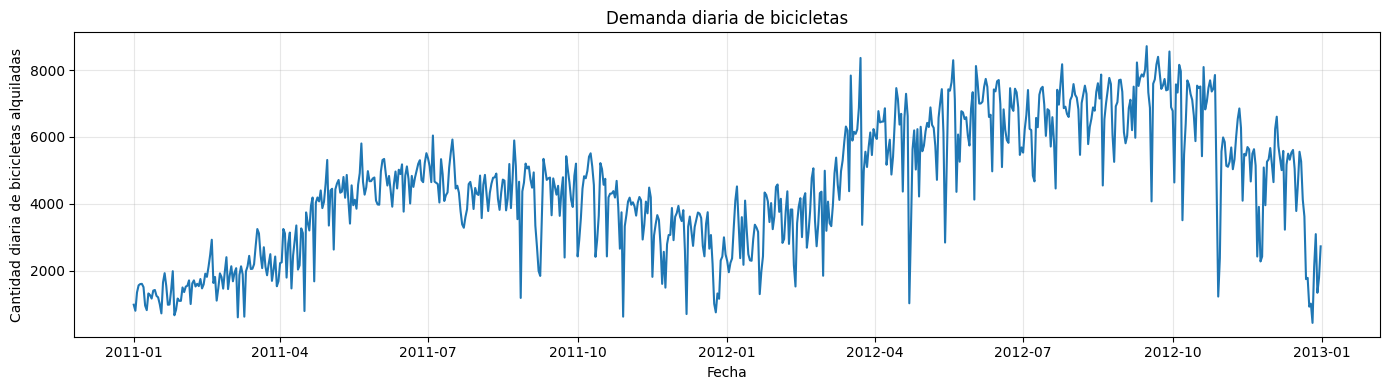

In [ ]:
# Graficamos nuevamente la serie completa para ubicar visualmente
# los valores altos o bajos que puedan resultar llamativos.
plt.figure(figsize=(14, 4))

plt.plot(df_diario.index, df_diario["cnt"])

plt.title("Demanda diaria de bicicletas")
plt.xlabel("Fecha")
plt.ylabel("Cantidad diaria de bicicletas alquiladas")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Autocorrelación de la demanda diaria

La autocorrelación permite analizar si los valores actuales de una serie se parecen a sus valores pasados.

En este caso vamos a comparar la demanda diaria con:

- la demanda del día anterior;
- la demanda de una semana atrás.

Luego vamos a graficar la función de autocorrelación, ACF, para observar cómo cambia esa relación al aumentar la cantidad de rezagos.

Este análisis es exploratorio y no modifica el DataFrame original.

,cnt,cnt_dia_anterior,cnt_semana_anterior
fecha,,,
2011-01-01,985,NaN,NaN
2011-01-02,803,985.0,NaN
2011-01-03,1352,803.0,NaN
2011-01-04,1564,1352.0,NaN
2011-01-05,1602,1564.0,NaN
2011-01-06,1608,1602.0,NaN
2011-01-07,1511,1608.0,NaN
2011-01-08,959,1511.0,985.0
2011-01-09,822,959.0,803.0


Autocorrelación con el día anterior: 0.851
Autocorrelación con una semana atrás: 0.765


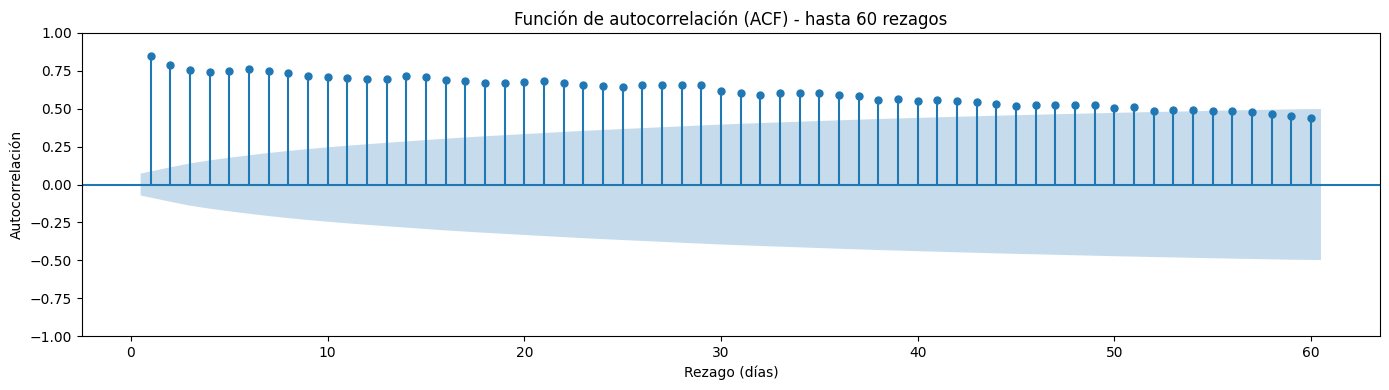

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

# Construimos una tabla auxiliar para comparar la demanda diaria
# con la demanda del día anterior.
comparacion = pd.DataFrame({
    "cnt": df_diario["cnt"],
    "cnt_dia_anterior": df_diario["cnt"].shift(1),
    "cnt_semana_anterior": df_diario["cnt"].shift(7)
})

# Mostramos las primeras filas de la comparación.
display(comparacion.head(10))

# Calculamos la autocorrelación con el día anterior.
autocorr_1_dia = df_diario["cnt"].corr(df_diario["cnt"].shift(1))

# Calculamos la autocorrelación con una semana de rezago.
autocorr_7_dias = df_diario["cnt"].corr(df_diario["cnt"].shift(7))

print("Autocorrelación con el día anterior:", round(autocorr_1_dia, 3))
print("Autocorrelación con una semana atrás:", round(autocorr_7_dias, 3))

# Definimos cuántos rezagos queremos mostrar en el gráfico ACF.
# Este valor se puede cambiar, por ejemplo a 30, 60 o 90.
n_rezagos = 60

# Graficamos la función de autocorrelación.

fig, ax = plt.subplots(figsize=(14, 4))

plot_acf(
    df_diario["cnt"].dropna(),
    lags=n_rezagos,
    zero=False,
    ax=ax
)

plt.title(f"Función de autocorrelación (ACF) - hasta {n_rezagos} rezagos")
plt.xlabel("Rezago (días)")
plt.ylabel("Autocorrelación")

plt.tight_layout()
plt.show()

## Autocorrelación parcial (PACF)

Además de la ACF, podemos analizar la función de autocorrelación parcial, conocida como PACF.

La PACF permite observar la relación directa entre la serie y cada rezago, descontando el efecto de los rezagos intermedios.

Esto puede ayudar a identificar qué rezagos podrían aportar información adicional al modelo, aunque la selección final de lags debe validarse luego mediante entrenamiento y backtesting.

Este análisis es exploratorio y no modifica el DataFrame.

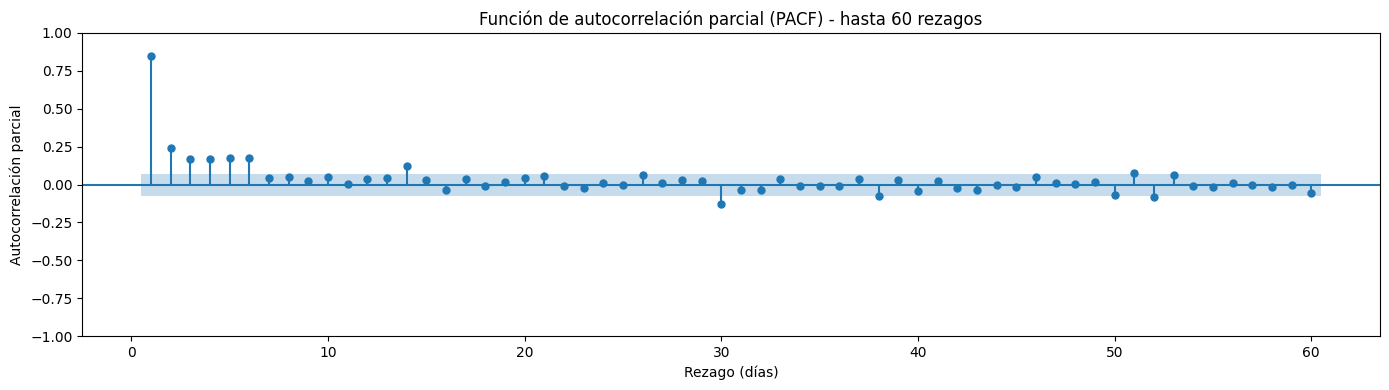

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

# Definimos cuántos rezagos queremos visualizar.
# Como estamos trabajando con datos diarios, 60 rezagos equivalen aproximadamente a dos meses.
n_rezagos = 60

# Creamos la figura y el eje para evitar que se genere una figura vacía.
fig, ax = plt.subplots(figsize=(14, 4))

# Graficamos la función de autocorrelación parcial.
plot_pacf(
    df_diario["cnt"].dropna(),
    lags=n_rezagos,
    method="ywm",
    zero=False,
    ax=ax
)

ax.set_title(f"Función de autocorrelación parcial (PACF) - hasta {n_rezagos} rezagos")
ax.set_xlabel("Rezago (días)")
ax.set_ylabel("Autocorrelación parcial")

plt.tight_layout()
plt.show()

Mientras que la ACF muestra cuánto se parece la serie a sus valores pasados, la PACF intenta mostrar qué rezagos tienen una relación más directa con la serie, quitando el efecto de los rezagos intermedios. Por eso puede servir como apoyo para proponer lags candidatos, aunque la decisión final se valida después con backtesting.

## Partición temporal en entrenamiento y prueba

Para trabajar con forecasting no debemos separar los datos de forma aleatoria.

En una serie temporal, el orden importa. Por eso, vamos a usar los primeros datos para entrenamiento y los datos más recientes para prueba.

En este ejemplo:

- el conjunto de entrenamiento contiene el 80% inicial de la serie;
- el conjunto de prueba contiene el 20% final.

De esta forma simulamos una situación real: entrenamos con el pasado y evaluamos sobre datos futuros.

In [ ]:
# Seleccionamos la serie objetivo diaria.
# Usamos solamente "cnt", que representa la cantidad diaria de bicicletas alquiladas.
serie = df_diario["cnt"].copy()

# Definimos el tamaño del conjunto de prueba.
# En este caso usamos el 20% final de la serie para test.
test_size = int(len(serie) * 0.2)

# Separamos respetando el orden temporal.
# Train contiene el primer 80% de la serie.
# Test contiene el último 20% de la serie.
train = serie.iloc[:-test_size]
test = serie.iloc[-test_size:]

# Mostramos la cantidad de observaciones en cada conjunto.
print("Cantidad de observaciones en train:", len(train))
print("Cantidad de observaciones en test:", len(test))

# Mostramos los rangos temporales de cada conjunto.
print("Rango de train:", train.index.min(), "a", train.index.max())
print("Rango de test:", test.index.min(), "a", test.index.max())

Cantidad de observaciones en train: 585
Cantidad de observaciones en test: 146
Rango de train: 2011-01-01 00:00:00 a 2012-08-07 00:00:00
Rango de test: 2012-08-08 00:00:00 a 2012-12-31 00:00:00


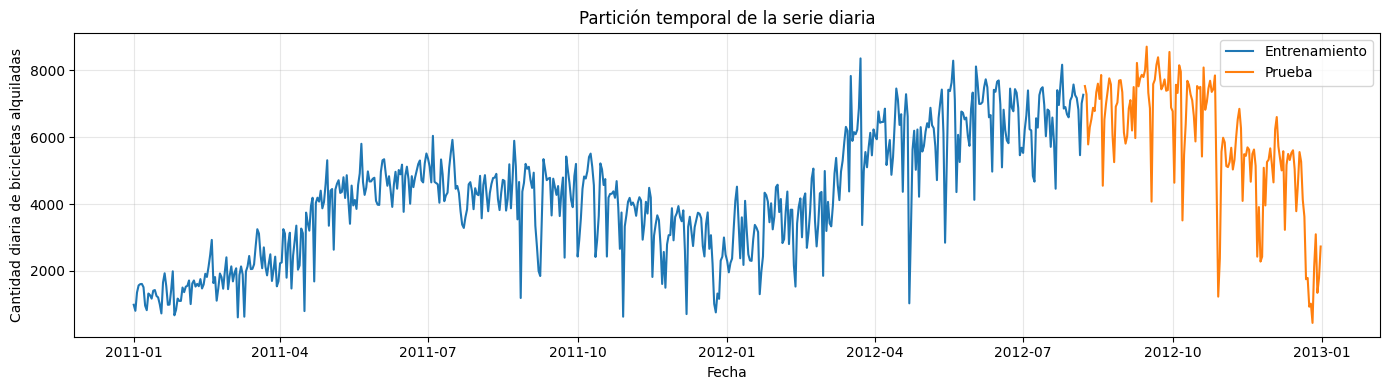

In [ ]:
# Graficamos la partición temporal para verificar visualmente
# que train queda antes que test.
plt.figure(figsize=(14, 4))

plt.plot(
    train.index,
    train,
    label="Entrenamiento"
)

plt.plot(
    test.index,
    test,
    label="Prueba"
)

plt.title("Partición temporal de la serie diaria")
plt.xlabel("Fecha")
plt.ylabel("Cantidad diaria de bicicletas alquiladas")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Primer modelo con skforecast - Recursivo**

Ahora vamos a crear el primer modelo de forecasting usando `skforecast`.

En este primer ejemplo vamos a trabajar solo con la serie objetivo, es decir, con la demanda diaria de bicicletas `cnt`.

Usaremos un forecaster recursivo con un modelo `RandomForestRegressor`.

En este caso:

- `y=train` indica que entrenamos usando solo la serie objetivo de entrenamiento;
- `lags=7` indica que el modelo usará los últimos 7 valores conocidos como entrada;
- `RandomForestRegressor` es el modelo de machine learning que `skforecast` utilizará internamente.

In [ ]:
# Instalamos skforecast en el entorno de Colab.
!pip install skforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.3/467.3 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 29.7 MB/s eta 0:00:00


In [ ]:
# Importamos el forecaster recursivo de skforecast.
from skforecast.recursive import ForecasterRecursive

# Importamos el modelo de machine learning que usaremos como estimador interno.
from sklearn.ensemble import RandomForestRegressor

# Creamos el forecaster recursivo.
# lags=7 indica que el modelo usará los últimos 7 valores de la serie
# para aprender a predecir el siguiente valor.
forecaster = ForecasterRecursive(
    estimator=RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    lags=7
)

# Entrenamos el forecaster usando solamente la serie objetivo de entrenamiento.
forecaster.fit(y=train)

# Mostramos el objeto entrenado para revisar su configuración.
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: RandomForestRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Series name: cnt 
Exogenous included: False 
Exogenous names: None 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2011-01-01 00:00:00'), Timestamp('2012-08-07 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2026-06-15 00:42:22 
Last fit date: 2026-06-15 00:42:25 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

## Primeras predicciones del modelo

Una vez entrenado el forecaster, vamos a generar las primeras predicciones sobre el conjunto de prueba.

En este ejemplo usamos un horizonte de 7 días:

- `steps=7` indica que queremos predecir los próximos 7 valores futuros;
- el modelo fue entrenado con `lags=7`, es decir, usando los últimos 7 valores conocidos como entrada;
- como el enfoque es recursivo, el modelo predice un paso y luego usa esa predicción para continuar prediciendo los pasos siguientes.

Aunque la variable `cnt` representa cantidades enteras de bicicletas alquiladas, el modelo utilizado es un regresor. Por eso puede devolver predicciones con decimales. Para la interpretación, también mostraremos una versión redondeada.

In [ ]:
# Definimos el horizonte de predicción.
# En este caso queremos predecir los próximos 7 días.
steps = 7

# Generamos las predicciones con el forecaster entrenado.
# predict(steps=steps) solicita al modelo una predicción recursiva
# para los próximos "steps" períodos.
predicciones = forecaster.predict(steps=steps)

# Asignamos a las predicciones el mismo índice temporal
# que tienen los primeros 7 valores del conjunto de prueba.
predicciones.index = test.iloc[:steps].index

# Creamos una versión redondeada para interpretar las predicciones
# como cantidades de bicicletas alquiladas.
predicciones_redondeadas = (
    predicciones
    .round()
    .clip(lower=0)
    .astype("int64")
)

# Construimos una tabla comparativa entre valores reales,
# predicciones continuas y predicciones redondeadas.
comparacion_predicciones = pd.DataFrame({
    "valor_real": test.iloc[:steps],
    "prediccion": predicciones,
    "prediccion_redondeada": predicciones_redondeadas
})

# Mostramos la comparación.
comparacion_predicciones

,valor_real,prediccion,prediccion_redondeada
fecha,,,
2012-08-08,7534,7148.28,7148
2012-08-09,7286,7141.46,7141
2012-08-10,5786,7069.20,7069
2012-08-11,6299,6836.01,6836
2012-08-12,6544,6092.89,6093
2012-08-13,6883,6205.98,6206
2012-08-14,6784,6233.45,6233


## Visualización de las primeras predicciones

Para interpretar mejor las primeras predicciones, vamos a graficarlas junto con una parte del conjunto de entrenamiento.

En el gráfico se muestran:

- los últimos 30 días del conjunto de entrenamiento;
- los valores reales del conjunto de prueba para el horizonte definido;
- las predicciones generadas por el modelo.

Esta visualización permite observar si las predicciones mantienen cierta continuidad con el comportamiento reciente de la serie y cómo se comparan con los primeros valores reales del período de prueba.

En este ejemplo, el gráfico tiene un objetivo exploratorio y didáctico. Todavía no representa una evaluación completa del modelo, ya que para eso más adelante utilizaremos métricas y técnicas de evaluación temporal como backtesting.

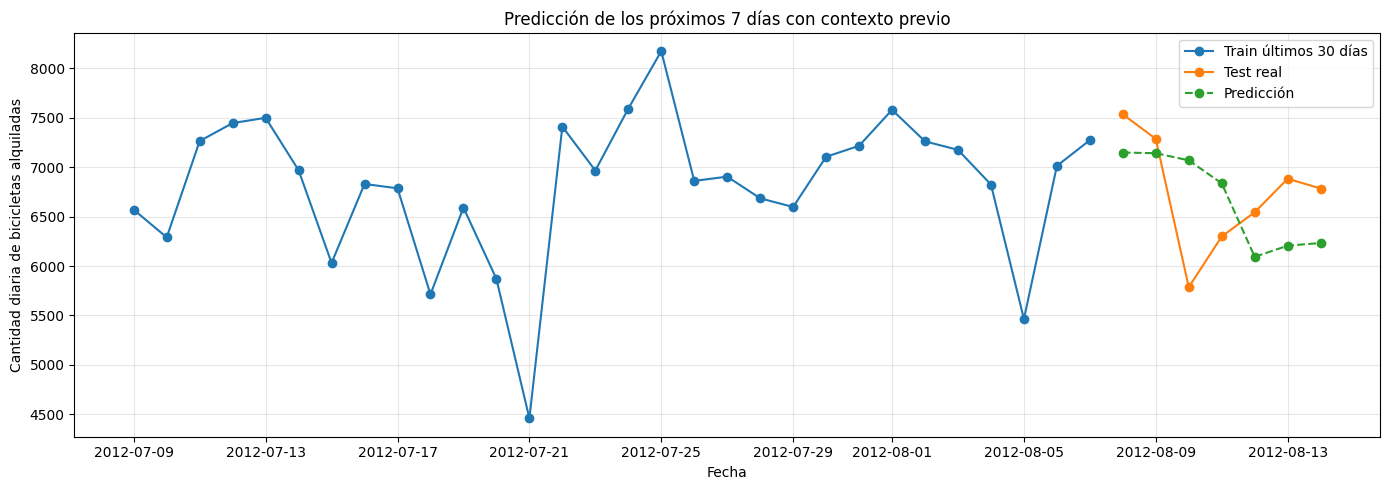

In [ ]:
# Definimos cuántos días anteriores del conjunto de entrenamiento queremos mostrar.
dias_contexto = 30

# Tomamos los últimos 30 días del conjunto de entrenamiento.
train_contexto = train.iloc[-dias_contexto:]

# Tomamos los valores reales del conjunto de prueba correspondientes al horizonte predicho.
test_real = test.iloc[:steps]

# Graficamos el contexto de train, los valores reales de test y las predicciones.
plt.figure(figsize=(14, 5))

plt.plot(
    train_contexto.index,
    train_contexto,
    marker="o",
    label="Train últimos 30 días"
)

plt.plot(
    test_real.index,
    test_real,
    marker="o",
    label="Test real"
)

plt.plot(
    predicciones_redondeadas.index,
    predicciones_redondeadas,
    marker="o",
    linestyle="--",
    label="Predicción"
)

plt.title("Predicción de los próximos 7 días con contexto previo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad diaria de bicicletas alquiladas")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluación inicial de las primeras predicciones

Ahora vamos a calcular dos métricas simples para evaluar las primeras predicciones del modelo:

- MAE: error absoluto medio. Indica, en promedio, cuántas bicicletas se desvía la predicción respecto al valor real.
- RMSE: raíz del error cuadrático medio. Penaliza más los errores grandes.

En esta primera evaluación usamos solamente los primeros 7 días del conjunto de prueba, porque ese fue el horizonte definido con `steps=7`.

Las métricas se calculan usando las predicciones continuas del modelo, no las predicciones redondeadas.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Tomamos los valores reales correspondientes al horizonte predicho.
y_real = test.iloc[:steps]

# Calculamos el MAE.
# Esta métrica indica el error absoluto promedio entre valores reales y predichos.
mae = mean_absolute_error(y_real, predicciones)

# Calculamos el RMSE.
# Esta métrica penaliza más los errores grandes.
rmse = np.sqrt(mean_squared_error(y_real, predicciones))

# Organizamos las métricas en una tabla.
metricas = pd.DataFrame({
    "Métrica": ["MAE", "RMSE"],
    "Valor": [mae, rmse]
})

# Redondeamos los valores para facilitar la lectura.
metricas["Valor"] = metricas["Valor"].round(2)

# Mostramos la tabla de métricas.
metricas

,Métrica,Valor
0,MAE,575.59
1,RMSE,662.21


# **Modelo con estrategia directa**

Ahora vamos a construir un segundo modelo usando la estrategia directa.

A diferencia del enfoque recursivo, donde se entrena un único modelo y sus propias predicciones se reutilizan para avanzar varios pasos, en la estrategia directa se entrenan modelos separados para cada paso del horizonte.

Por ejemplo, si definimos `steps=7`, el forecaster entrena modelos específicos para predecir:

- el día 1 del horizonte;
- el día 2 del horizonte;
- el día 3 del horizonte;
- y así hasta el día 7.

En este ejemplo mantenemos `lags=7`, por lo que cada modelo usará los últimos 7 valores conocidos de la serie como entrada.

In [ ]:
# Importamos el forecaster directo de skforecast.
from skforecast.direct import ForecasterDirect

# Importamos el modelo de machine learning que usaremos como estimador interno.
from sklearn.ensemble import RandomForestRegressor

# Definimos el horizonte máximo que queremos que el modelo aprenda a predecir.
# En este caso, queremos entrenar modelos directos para los próximos 7 días.
steps_direct = 7

# Definimos la cantidad de rezagos que usará cada modelo.
# lags=7 significa que se usarán los últimos 7 valores conocidos de la serie.
lags_direct = 7

# Creamos el forecaster directo.
# Este forecaster entrenará un modelo diferente para cada paso del horizonte.
forecaster_direct = ForecasterDirect(
    estimator=RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    steps=steps_direct,
    lags=lags_direct
)

# Entrenamos el forecaster usando solamente la serie objetivo de entrenamiento.
forecaster_direct.fit(y=train)

# Mostramos el objeto entrenado para revisar su configuración.
forecaster_direct

================ 
ForecasterDirect 
================ 
Estimator: RandomForestRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Maximum steps to predict: 7 
Series name: cnt 
Exogenous included: False 
Exogenous names: None 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2011-01-01 00:00:00'), Timestamp('2012-08-07 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2026-06-15 00:42:47 
Last fit date: 2026-06-15 00:42:51 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

## Predicciones con el modelo directo

Una vez entrenado el forecaster directo, podemos generar predicciones para el horizonte definido.

En este caso, el modelo fue entrenado con `steps_direct = 7`, por lo que tiene modelos específicos para predecir hasta 7 días hacia adelante.

Podemos pedir el horizonte completo o una cantidad menor de pasos. En este ejemplo vamos a predecir los próximos 7 días para compararlos con los primeros valores del conjunto de prueba.

A diferencia del enfoque recursivo, acá cada paso del horizonte es predicho por un modelo entrenado específicamente para ese paso.

In [ ]:
# Definimos cuántos pasos hacia adelante queremos predecir.
# Este valor debe ser menor o igual al horizonte usado al entrenar el modelo directo.
steps_predict = 7

# Generamos las predicciones con el forecaster directo.
predicciones_direct = forecaster_direct.predict(steps=steps_predict)

# Asignamos a las predicciones el mismo índice temporal
# que tienen los primeros valores del conjunto de prueba.
predicciones_direct.index = test.iloc[:steps_predict].index

# Creamos una versión redondeada para interpretar las predicciones
# como cantidades de bicicletas alquiladas.
predicciones_direct_redondeadas = (
    predicciones_direct
    .round()
    .clip(lower=0)
    .astype("int64")
)

# Construimos una tabla comparativa entre valores reales,
# predicciones continuas y predicciones redondeadas.
comparacion_direct = pd.DataFrame({
    "valor_real": test.iloc[:steps_predict],
    "prediccion_directa": predicciones_direct,
    "prediccion_directa_redondeada": predicciones_direct_redondeadas
})

# Mostramos la comparación.
comparacion_direct

,valor_real,prediccion_directa,prediccion_directa_redondeada
fecha,,,
2012-08-08,7534,6987.22,6987
2012-08-09,7286,6884.91,6885
2012-08-10,5786,6426.55,6427
2012-08-11,6299,5895.02,5895
2012-08-12,6544,6908.55,6909
2012-08-13,6883,6823.61,6824
2012-08-14,6784,6900.52,6901


## Visualización de las predicciones directas

Para interpretar mejor las predicciones, vamos a graficarlas junto con una parte reciente del conjunto de entrenamiento.

En el gráfico se muestran:

- los últimos 30 días del conjunto de entrenamiento;
- los valores reales del conjunto de prueba;
- las predicciones generadas con la estrategia directa.

Esta visualización permite observar si las predicciones mantienen continuidad con el comportamiento reciente de la serie y cómo se comparan con los valores reales del horizonte evaluado.

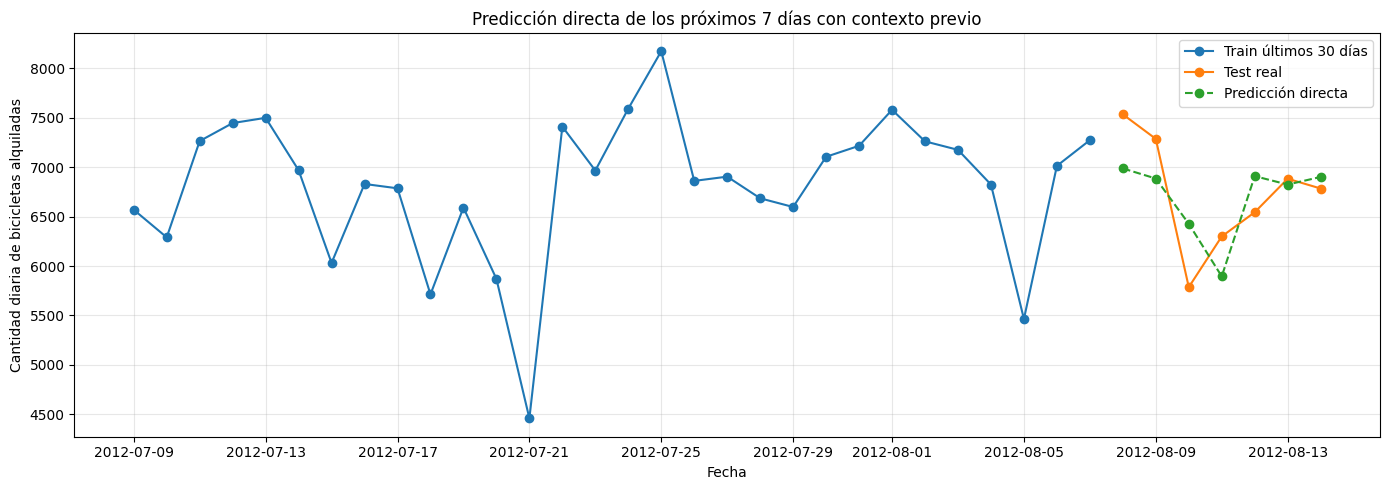

In [ ]:
# Definimos cuántos días anteriores del conjunto de entrenamiento queremos mostrar.
dias_contexto = 30

# Tomamos los últimos 30 días del conjunto de entrenamiento.
train_contexto = train.iloc[-dias_contexto:]

# Tomamos los valores reales del conjunto de prueba correspondientes al horizonte predicho.
test_real_direct = test.iloc[:steps_predict]

# Graficamos el contexto de train, los valores reales de test y las predicciones directas.
plt.figure(figsize=(14, 5))

plt.plot(
    train_contexto.index,
    train_contexto,
    marker="o",
    label="Train últimos 30 días"
)

plt.plot(
    test_real_direct.index,
    test_real_direct,
    marker="o",
    label="Test real"
)

plt.plot(
    predicciones_direct_redondeadas.index,
    predicciones_direct_redondeadas,
    marker="o",
    linestyle="--",
    label="Predicción directa"
)

plt.title("Predicción directa de los próximos 7 días con contexto previo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad diaria de bicicletas alquiladas")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluación inicial del modelo directo

Ahora vamos a calcular las métricas MAE y RMSE para las predicciones generadas con la estrategia directa.

Usaremos el mismo horizonte que en el modelo recursivo, es decir, los primeros 7 días del conjunto de prueba.

Luego compararemos ambos enfoques:

- modelo recursivo;
- modelo directo.

Esta comparación es todavía inicial, porque se basa solamente en una primera predicción de 7 días. Más adelante, la evaluación más completa se realizará con backtesting.

In [ ]:
# Tomamos los valores reales correspondientes al horizonte predicho.
y_real_direct = test.iloc[:steps_predict]

# Calculamos el MAE del modelo directo.
mae_direct = mean_absolute_error(y_real_direct, predicciones_direct)

# Calculamos el RMSE del modelo directo.
rmse_direct = np.sqrt(mean_squared_error(y_real_direct, predicciones_direct))

# Organizamos las métricas del modelo directo en una tabla.
metricas_direct = pd.DataFrame({
    "Métrica": ["MAE", "RMSE"],
    "Valor": [mae_direct, rmse_direct]
})

# Redondeamos los valores para facilitar la lectura.
metricas_direct["Valor"] = metricas_direct["Valor"].round(2)

# Mostramos las métricas del modelo directo.
metricas_direct

,Métrica,Valor
0,MAE,361.84
1,RMSE,411.16


## Comparación inicial entre estrategia recursiva y directa

Ahora comparamos las métricas obtenidas por los dos enfoques.

Esta comparación permite observar cuál estrategia tuvo menor error en esta primera predicción de 7 días.

Sin embargo, esta conclusión debe tomarse como preliminar, porque una única ventana de predicción puede no representar el comportamiento general del modelo.

In [ ]:
# Para comparar ambos modelos, usamos el mismo horizonte de evaluación.
y_real_comparacion = test.iloc[:steps_predict]

# Calculamos nuevamente las métricas del modelo recursivo sobre el mismo horizonte.
mae_recursivo = mean_absolute_error(y_real_comparacion, predicciones)
rmse_recursivo = np.sqrt(mean_squared_error(y_real_comparacion, predicciones))

# Calculamos las métricas del modelo directo.
mae_directo = mean_absolute_error(y_real_comparacion, predicciones_direct)
rmse_directo = np.sqrt(mean_squared_error(y_real_comparacion, predicciones_direct))

# Creamos una tabla comparativa.
comparacion_metricas = pd.DataFrame({
    "Modelo": ["Recursivo", "Directo"],
    "MAE": [mae_recursivo, mae_directo],
    "RMSE": [rmse_recursivo, rmse_directo]
})

# Redondeamos los valores para facilitar la lectura.
comparacion_metricas[["MAE", "RMSE"]] = comparacion_metricas[["MAE", "RMSE"]].round(2)

# Mostramos la comparación.
comparacion_metricas

,Modelo,MAE,RMSE
0,Recursivo,575.59,662.21
1,Directo,361.84,411.16


## **Configuración de la validación temporal interna**

Ya tenemos una partición temporal general:

train | test

En esta etapa vamos a trabajar solamente dentro de `train`.

El conjunto `test` no se usará todavía, porque quedará reservado para evaluar más adelante una configuración ya seleccionada.

Para hacer validación temporal interna, tomaremos una parte inicial de `train` para entrenar y dejaremos el resto de `train` disponible para los cortes sucesivos de backtesting.

Esto permite evaluar configuraciones respetando el orden temporal, sin usar todavía los datos de prueba.

In [ ]:
# Confirmamos el tamaño de la partición temporal general.
print("Tamaño de train:", len(train))
print("Tamaño de test:", len(test))

print("Rango de train:", train.index.min(), "a", train.index.max())
print("Rango de test:", test.index.min(), "a", test.index.max())

Tamaño de train: 585
Tamaño de test: 146
Rango de train: 2011-01-01 00:00:00 a 2012-08-07 00:00:00
Rango de test: 2012-08-08 00:00:00 a 2012-12-31 00:00:00


In [ ]:
# Definimos la serie que se usará para la validación interna.
# En nuestro notebook, train ya contiene solamente la variable objetivo cnt.
y_train = train.copy()

# Definimos el horizonte de predicción para cada corte temporal.
steps = 7

# Definimos el tamaño inicial de entrenamiento interno.
# Usamos el 70% inicial de train.
initial_train_size = int(len(y_train) * 0.7)

# Mostramos los tamaños para entender la lógica de validación.
print("Tamaño total de y_train:", len(y_train))
print("Tamaño inicial de entrenamiento interno:", initial_train_size)
print("Datos disponibles para validación interna:", len(y_train) - initial_train_size)

Tamaño total de y_train: 585
Tamaño inicial de entrenamiento interno: 409
Datos disponibles para validación interna: 176


In [ ]:
# Importamos la herramienta para definir cortes temporales en skforecast.
from skforecast.model_selection import TimeSeriesFold

# Configuramos el esquema de validación temporal interna.
# La evaluación se realizará dentro de train, no sobre test.
cv = TimeSeriesFold(
    steps=steps,
    initial_train_size=initial_train_size,
    refit=True,
    fixed_train_size=False
)

# Mostramos la configuración creada.
cv

============== 
TimeSeriesFold 
============== 
Initial train size    = 409,
Steps                 = 7,
Fold stride           = 7,
Overlapping folds     = False,
Window size           = None,
Differentiation       = None,
Refit                 = True,
Fixed train size      = False,
Gap                   = 0,
Skip folds            = None,
Allow incomplete fold = True,
Return all indexes    = False,
Verbose               = True

## Backtesting interno del modelo base

Ahora vamos a evaluar el modelo base univariante dentro del conjunto de entrenamiento.

En esta etapa seguimos trabajando solo con `train`.  
El conjunto `test` queda reservado para más adelante.

El objetivo es obtener una evaluación temporal más sólida del modelo base inicial, usando varios cortes internos dentro de `train`.

Este modelo base:

- usa solo la variable objetivo;
- utiliza `lags=7`;
- emplea un `RandomForestRegressor` con una configuración simple;
- se evalúa con MAE mediante backtesting interno.

In [ ]:
# Creamos una nueva instancia del modelo base para evaluarlo con backtesting interno.
# Usamos la misma configuración inicial del modelo recursivo:
# RandomForestRegressor con parámetros simples y lags=7.
forecaster_base = ForecasterRecursive(
    estimator=RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    lags=7
)

# Mostramos la configuración del modelo base.
forecaster_base

=================== 
ForecasterRecursive 
=================== 
Estimator: RandomForestRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Series name: None 
Exogenous included: False 
Exogenous names: None 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: None 
Training index type: None 
Training index frequency: None 
Estimator parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2026-06-15 00:43:57 
Last fit date: None 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

In [ ]:
# Importamos la función para ejecutar backtesting.
from skforecast.model_selection import backtesting_forecaster

# Ejecutamos el backtesting interno dentro de train.
# La serie usada es y_train, por lo tanto test no participa en esta evaluación.
# verbose=True permite visualizar cómo se realizan los cortes temporales.
metrica_base, predicciones_base = backtesting_forecaster(
    forecaster=forecaster_base,
    y=y_train,
    cv=cv,
    metric="mean_absolute_error",
    verbose=True,
    show_progress=True
)

Information of folds
--------------------
Number of observations used for initial training: 409
Number of observations used for backtesting: 176
    Number of folds: 26
    Number skipped folds: 0 
    Number of steps per fold: 7
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0
    Last fold only includes 1 observations.

Fold: 0
    Training:   2011-01-01 00:00:00 -- 2012-02-13 00:00:00  (n=409)
    Validation: 2012-02-14 00:00:00 -- 2012-02-20 00:00:00  (n=7)
Fold: 1
    Training:   2011-01-01 00:00:00 -- 2012-02-20 00:00:00  (n=416)
    Validation: 2012-02-21 00:00:00 -- 2012-02-27 00:00:00  (n=7)
Fold: 2
    Training:   2011-01-01 00:00:00 -- 2012-02-27 00:00:00  (n=423)
    Validation: 2012-02-28 00:00:00 -- 2012-03-05 00:00:00  (n=7)
Fold: 3
    Training:   2011-01-01 00:00:00 -- 2012-03-05 00:00:00  (n=430)
    Validation: 2012-03-06 00:00:00 -- 2012-03-12 00:00:00  (n=7)
Fold: 4
    Training:   2011-01-01 00:00:00 -- 2012-03-12 00

  0%|          | 0/26 [00:00<?, ?it/s]

In [ ]:
# Mostramos la métrica obtenida para el modelo base.
metrica_base

,mean_absolute_error
0,1016.72608


In [ ]:
# Mostramos las primeras predicciones generadas por el backtesting interno.
predicciones_base.head()

,fold,pred
2012-02-14,0,3675.31
2012-02-15,0,3414.79
2012-02-16,0,3282.15
2012-02-17,0,3171.08
2012-02-18,0,2018.77


## Visualización del backtesting interno del modelo base

Ahora vamos a graficar los resultados del backtesting interno.

En el gráfico se mostrará:

- la serie real completa de entrenamiento (`y_train`);
- las predicciones generadas por el backtesting, solo en los puntos donde efectivamente fueron calculadas.

Esto permite observar:

- desde qué momento comienzan las predicciones;
- si el modelo acompaña la tendencia general de la serie;
- en qué tramos parece acercarse más o menos a los valores reales.

El objetivo de esta visualización es complementar la métrica con una interpretación gráfica del desempeño del modelo base.

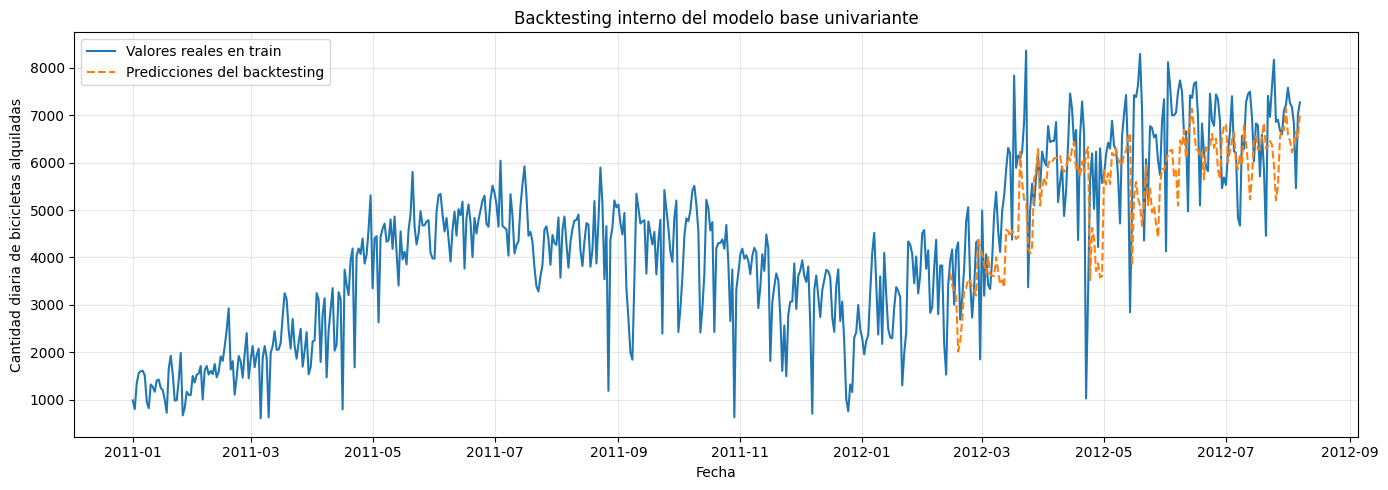

In [ ]:
# Graficamos la serie real completa de entrenamiento
# junto con las predicciones generadas por el backtesting interno.
plt.figure(figsize=(14, 5))

plt.plot(
    y_train.index,
    y_train,
    label="Valores reales en train"
)

plt.plot(
    predicciones_base.index,
    predicciones_base["pred"],
    label="Predicciones del backtesting",
    linestyle="--"
)

plt.title("Backtesting interno del modelo base univariante")
plt.xlabel("Fecha")
plt.ylabel("Cantidad diaria de bicicletas alquiladas")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Elementos que vamos a ajustar

El modelo base fue construido con una configuración simple:

- `lags = 7`
- `RandomForestRegressor` con parámetros básicos

Esto significa que el modelo usaba una ventana de 7 períodos anteriores para predecir el siguiente valor.

Ahora vamos a preparar una búsqueda pequeña para probar distintas ventanas de lags y algunos hiperparámetros del regresor.

Todavía no ejecutamos la búsqueda. En esta etapa solo definimos las opciones candidatas.

In [ ]:
# Definimos las ventanas candidatas de lags que se evaluarán en el Grid Search.
# Cada número representa el tamaño de la ventana temporal usada como entrada.
#
# Por ejemplo:
# 1  -> usa solo el último valor disponible
# 2  -> usa los últimos 2 valores
# 7  -> usa los últimos 7 valores
# 14 -> usa los últimos 14 valores
# 30 -> usa los últimos 30 valores
lags_grid = [1, 2, 3, 4, 5, 6, 7, 14, 30]

lags_grid

[1, 2, 3, 4, 5, 6, 7, 14, 30]

In [ ]:
# Definimos una grilla pequeña de hiperparámetros para RandomForestRegressor.
# Esta búsqueda se mantiene acotada para que el notebook sea ejecutable
# y los resultados sean fáciles de interpretar.
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None]
}

param_grid

{'n_estimators': [100, 200], 'max_depth': [5, 10, None]}

## Grid Search temporal del modelo univariante

Ahora vamos a ejecutar una búsqueda pequeña de lags e hiperparámetros.

La búsqueda se realiza dentro de `train`, usando el esquema de validación temporal interna definido en `cv`.

En esta etapa no usamos `test`.

El objetivo es comparar distintas combinaciones de:

- ventanas de lags;
- hiperparámetros del Random Forest.

La métrica principal será MAE.

In [ ]:
# Importamos la función para ejecutar Grid Search con skforecast.
from skforecast.model_selection import grid_search_forecaster

# Ejecutamos la búsqueda de lags e hiperparámetros.
# Usamos y_train, por lo tanto la búsqueda se realiza solo dentro de train.
resultados_grid = grid_search_forecaster(
    forecaster=forecaster_base,
    y=y_train,
    cv=cv,
    lags_grid=lags_grid,
    param_grid=param_grid,
    metric="mean_absolute_error",
    return_best=True,
    verbose=False,
    show_progress=True
)

lags grid:   0%|          | 0/9 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
# Mostramos las primeras filas de la tabla de resultados.
resultados_grid.head()

,lags,lags_label,params,mean_absolute_error,max_depth,n_estimators
0,"[1, 2, 3, 4, 5, 6]","[1, 2, 3, 4, 5, 6]","{'max_depth': 10, 'n_estimators': 200}",962.347466,10.0,200.0
1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 5, 'n_estimators': 200}",973.845610,5.0,200.0
2,"[1, 2, 3, 4, 5, 6]","[1, 2, 3, 4, 5, 6]","{'max_depth': 5, 'n_estimators': 200}",978.455503,5.0,200.0
3,"[1, 2, 3, 4, 5, 6]","[1, 2, 3, 4, 5, 6]","{'max_depth': None, 'n_estimators': 200}",978.484744,NaN,200.0
4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 5, 'n_estimators': 100}",984.900331,5.0,100.0


In [ ]:
# Revisamos las columnas principales para interpretar la búsqueda.
resultados_grid[["lags", "params", "mean_absolute_error"]].head()

,lags,params,mean_absolute_error
0,"[1, 2, 3, 4, 5, 6]","{'max_depth': 10, 'n_estimators': 200}",962.347466
1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 5, 'n_estimators': 200}",973.845610
2,"[1, 2, 3, 4, 5, 6]","{'max_depth': 5, 'n_estimators': 200}",978.455503
3,"[1, 2, 3, 4, 5, 6]","{'max_depth': None, 'n_estimators': 200}",978.484744
4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 5, 'n_estimators': 100}",984.900331


## Tamaño de la grilla de búsqueda

Antes de ejecutar una búsqueda de hiperparámetros, conviene revisar cuántas combinaciones vamos a probar.

La cantidad total de combinaciones depende de:

- la cantidad de opciones de `lags`;
- la cantidad de combinaciones de hiperparámetros del regresor.

Esto es importante porque cada combinación será evaluada mediante validación temporal interna, por lo que una grilla muy grande puede generar muchos entrenamientos.

In [ ]:
import math

# Calculamos cuántas opciones de lags vamos a probar.
n_lags = len(lags_grid)

# Calculamos cuántas combinaciones de hiperparámetros hay en param_grid.
n_params = 1

for valores in param_grid.values():
    n_params *= len(valores)

# Calculamos el total de combinaciones de la grilla.
n_combinaciones = n_lags * n_params

# Calculamos cuántas observaciones de y_train quedan disponibles
# para la validación temporal interna.
n_validacion = len(y_train) - initial_train_size

# Calculamos una estimación de la cantidad de folds.
# Como en cada fold se predicen "steps" períodos, dividimos la zona
# de validación interna entre el horizonte de predicción.
n_folds_estimados = math.ceil(n_validacion / steps)

# Como refit=True, cada combinación se vuelve a entrenar en cada fold.
n_entrenamientos_estimados = n_combinaciones * n_folds_estimados

# Si usamos return_best=True en grid_search_forecaster,
# skforecast entrena una vez más el mejor modelo usando todo y_train.
return_best = True

if return_best:
    n_entrenamientos_totales = n_entrenamientos_estimados + 1
else:
    n_entrenamientos_totales = n_entrenamientos_estimados

print("Cantidad de opciones de lags:", n_lags)
print("Cantidad de combinaciones de hiperparámetros:", n_params)
print("Cantidad total de combinaciones a evaluar:", n_combinaciones)
print("Datos disponibles para validación interna:", n_validacion)
print("Cantidad estimada de folds:", n_folds_estimados)
print("Entrenamientos estimados durante el Grid Search:", n_entrenamientos_estimados)
print("Entrenamientos estimados totales:", n_entrenamientos_totales)

Cantidad de opciones de lags: 9
Cantidad de combinaciones de hiperparámetros: 6
Cantidad total de combinaciones a evaluar: 54
Datos disponibles para validación interna: 176
Cantidad estimada de folds: 26
Entrenamientos estimados durante el Grid Search: 1404
Entrenamientos estimados totales: 1405


## Mejor configuración encontrada

Ahora vamos a extraer solamente la mejor configuración encontrada por el Grid Search.

La tabla `resultados_grid` está ordenada según la métrica principal utilizada en la búsqueda.  
Por eso, la primera fila corresponde a la configuración con menor MAE dentro de la validación temporal interna.

Esta selección fue realizada usando `y_train`, no el conjunto `test`.

In [ ]:
# Extraemos la primera fila de resultados_grid.
# Esa fila corresponde a la mejor configuración según la métrica principal.
mejor_configuracion = resultados_grid.iloc[0]

print("Mejor configuración encontrada")
print("--------------------------------")
print("Lags seleccionados:")
print(mejor_configuracion["lags"])

print("\nHiperparámetros seleccionados:")
print(mejor_configuracion["params"])

print("\nMAE en validación temporal interna:")
print(round(mejor_configuracion["mean_absolute_error"], 2))

Mejor configuración encontrada
--------------------------------
Lags seleccionados:
[1 2 3 4 5 6]

Hiperparámetros seleccionados:
{'max_depth': 10, 'n_estimators': 200}

MAE en validación temporal interna:
962.35


Como usamos `return_best=True`, el objeto `forecaster_base` queda actualizado con la mejor configuración encontrada.

Esto no significa que el modelo ya fue evaluado en `test`.  
Significa que, dentro de `train`, esta fue la mejor combinación entre las opciones evaluadas.


## Visualización del modelo ajustado

El Grid Search ya seleccionó la mejor configuración usando validación temporal interna sobre `y_train`.

Como usamos `return_best=True`, el objeto `forecaster_base` quedó actualizado con esa mejor configuración.

Ahora ejecutamos nuevamente el backtesting solo para recuperar las predicciones del modelo ajustado y poder graficarlas. Esta ejecución no cambia la selección del modelo.

In [ ]:
# Ejecutamos nuevamente el backtesting interno solo para obtener
# las predicciones del modelo ajustado.
# El modelo ya fue seleccionado previamente por el Grid Search.
metrica_ajustado, predicciones_ajustado = backtesting_forecaster(
    forecaster=forecaster_base,
    y=y_train,
    cv=cv,
    metric="mean_absolute_error",
    verbose=False,
    show_progress=True
)

# Mostramos la métrica obtenida por el modelo ajustado.
metrica_ajustado

  0%|          | 0/26 [00:00<?, ?it/s]

,mean_absolute_error
0,962.347466


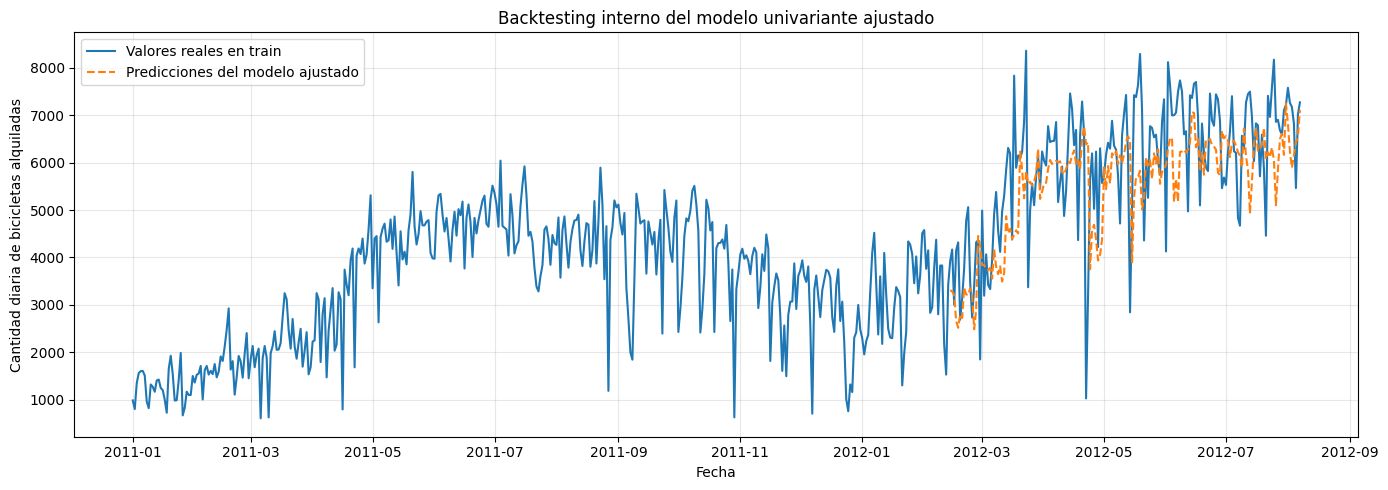

In [ ]:
# Graficamos la serie real de entrenamiento junto con las predicciones
# generadas por el modelo ajustado durante el backtesting interno.
plt.figure(figsize=(14, 5))

plt.plot(
    y_train.index,
    y_train,
    label="Valores reales en train"
)

plt.plot(
    predicciones_ajustado.index,
    predicciones_ajustado["pred"],
    label="Predicciones del modelo ajustado",
    linestyle="--"
)

plt.title("Backtesting interno del modelo univariante ajustado")
plt.xlabel("Fecha")
plt.ylabel("Cantidad diaria de bicicletas alquiladas")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluación final sobre test

Ahora vamos a evaluar el modelo ajustado sobre el conjunto `test`.

Hasta este punto, el conjunto `test` no fue usado para seleccionar lags ni hiperparámetros.  
La mejor configuración fue elegida mediante validación temporal interna dentro de `y_train`.

En esta etapa:

- usamos `test` por primera vez;
- el modelo ya tiene una configuración fija;
- no se realiza una nueva búsqueda de hiperparámetros;
- el backtesting final solo evalúa el desempeño del modelo ajustado sobre datos futuros.

Si se compararan varios modelos, todos deberían evaluarse usando este mismo protocolo final.

In [ ]:
# Definimos la serie de test.
# En nuestro notebook, test ya contiene solamente la variable objetivo cnt.
y_test = test.copy()

# Construimos la serie completa para que el backtesting pueda:
# 1. entrenar inicialmente con todo y_train;
# 2. evaluar a partir del inicio de y_test.
y_total = pd.concat([y_train, y_test])

# Verificamos los tamaños.
print("Tamaño de y_train:", len(y_train))
print("Tamaño de y_test:", len(y_test))
print("Tamaño total:", len(y_total))

print("Fin de y_train:", y_train.index.max())
print("Inicio de y_test:", y_test.index.min())

Tamaño de y_train: 585
Tamaño de y_test: 146
Tamaño total: 731
Fin de y_train: 2012-08-07 00:00:00
Inicio de y_test: 2012-08-08 00:00:00


In [ ]:
# Configuramos el protocolo de evaluación final.
# initial_train_size=len(y_train) hace que la evaluación comience justo al inicio de test.
# refit=True permite simular un uso operativo: el modelo se actualiza a medida que avanza el tiempo,
# pero sin cambiar lags ni hiperparámetros.
cv_test = TimeSeriesFold(
    steps=steps,
    initial_train_size=len(y_train),
    refit=False,
    fixed_train_size=False
)

cv_test

============== 
TimeSeriesFold 
============== 
Initial train size    = 585,
Steps                 = 7,
Fold stride           = 7,
Overlapping folds     = False,
Window size           = None,
Differentiation       = None,
Refit                 = False,
Fixed train size      = False,
Gap                   = 0,
Skip folds            = None,
Allow incomplete fold = True,
Return all indexes    = False,
Verbose               = True

In [ ]:
# Ejecutamos el backtesting final sobre y_total.
# La configuración del modelo ya fue seleccionada previamente dentro de train.
# Aquí no se realiza una nueva búsqueda de hiperparámetros.
metrica_test, predicciones_test = backtesting_forecaster(
    forecaster=forecaster_base,
    y=y_total,
    cv=cv_test,
    metric="mean_absolute_error",
    verbose=False,
    show_progress=True
)

# Mostramos la métrica final en test.
metrica_test

  0%|          | 0/21 [00:00<?, ?it/s]

,mean_absolute_error
0,1155.876529


In [ ]:
# Mostramos las primeras predicciones generadas sobre el tramo de test.
predicciones_test.head()

,fold,pred
2012-08-08,0,6964.195851
2012-08-09,0,6853.907022
2012-08-10,0,6567.384657
2012-08-11,0,5820.836943
2012-08-12,0,6257.794598


## Visualización de la evaluación final sobre test

Ahora vamos a visualizar el resultado del backtesting final sobre `test`.

En el gráfico se mostrarán:

- los últimos 30 días de `y_train`, para dar contexto;
- los valores reales del conjunto `test`;
- las predicciones generadas durante la evaluación final.

Esto permite observar cómo se comporta el modelo ajustado al pasar desde el final del entrenamiento hacia datos futuros no utilizados en la selección de hiperparámetros.

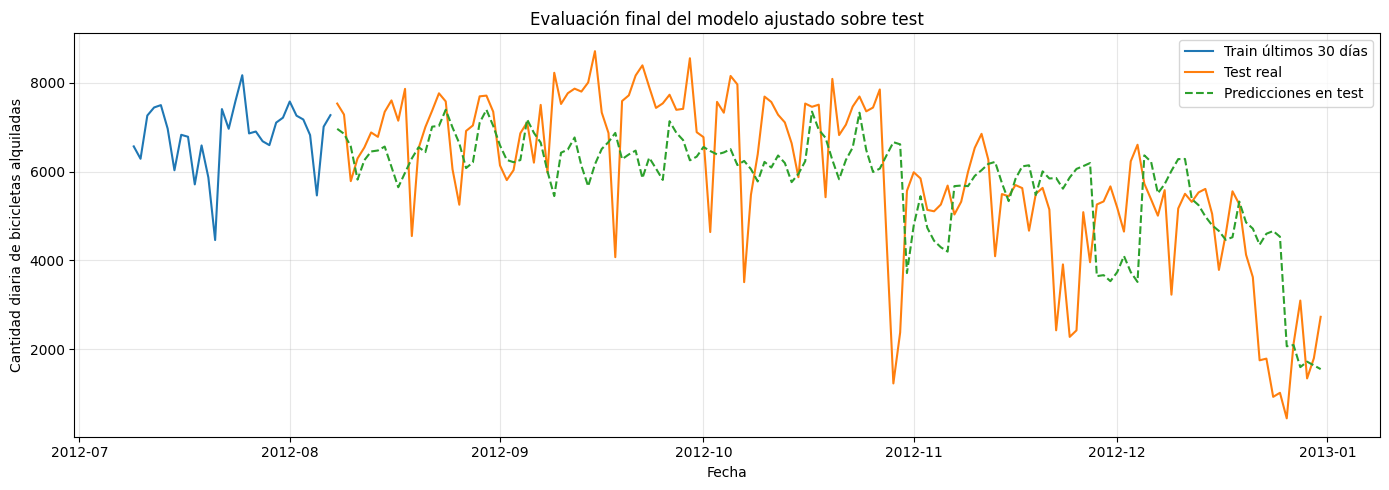

In [ ]:
# Definimos cuántos días finales de train queremos mostrar como contexto.
dias_contexto = 30

# Tomamos el tramo final de y_train para dar contexto al inicio de test.
train_contexto = y_train.iloc[-dias_contexto:]

# Graficamos el contexto de train, los valores reales de test
# y las predicciones generadas en la evaluación final.
plt.figure(figsize=(14, 5))

plt.plot(
    train_contexto.index,
    train_contexto,
    label="Train últimos 30 días"
)

plt.plot(
    y_test.index,
    y_test,
    label="Test real"
)

plt.plot(
    predicciones_test.index,
    predicciones_test["pred"],
    linestyle="--",
    label="Predicciones en test"
)

plt.title("Evaluación final del modelo ajustado sobre test")
plt.xlabel("Fecha")
plt.ylabel("Cantidad diaria de bicicletas alquiladas")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Comparación final de métricas

Finalmente vamos a organizar las métricas principales en una tabla comparativa.

Compararemos:

- el modelo base evaluado con backtesting interno sobre `y_train`;
- el modelo ajustado seleccionado por Grid Search dentro de `y_train`;
- el modelo ajustado evaluado finalmente sobre `test`.

Es importante recordar que el Grid Search se hizo dentro de `train`.  
El resultado sobre `test` corresponde a una evaluación posterior, sin nueva búsqueda de hiperparámetros.

In [ ]:
# Extraemos el MAE del modelo base evaluado con backtesting interno.
mae_base_train = metrica_base["mean_absolute_error"].iloc[0]

# Extraemos el MAE del mejor modelo ajustado según el Grid Search interno.
mae_ajustado_train = resultados_grid.iloc[0]["mean_absolute_error"]

# Extraemos el MAE del modelo ajustado evaluado finalmente sobre test.
mae_ajustado_test = metrica_test["mean_absolute_error"].iloc[0]

# Construimos una tabla comparativa.
comparacion_final = pd.DataFrame({
    "Etapa": [
        "Modelo base - validación interna en train",
        "Modelo ajustado - validación interna en train",
        "Modelo ajustado - evaluación final en test"
    ],
    "MAE": [
        mae_base_train,
        mae_ajustado_train,
        mae_ajustado_test
    ]
})

# Redondeamos para facilitar la lectura.
comparacion_final["MAE"] = comparacion_final["MAE"].round(2)

comparacion_final

,Etapa,MAE
0,Modelo base - validación interna en train,1016.73
1,Modelo ajustado - validación interna en train,962.35
2,Modelo ajustado - evaluación final en test,1155.88


## **Forecasting multivariante con variables exógenas**

Hasta ahora trabajamos con un modelo univariante, es decir, el modelo usó solamente la historia de la variable objetivo `cnt` para generar predicciones.

A partir de este punto vamos a incorporar variables exógenas.

Una variable exógena es una variable adicional que puede aportar información útil para predecir la variable objetivo, pero que no es la propia serie a predecir.

En este dataset, además de la demanda diaria de bicicletas, tenemos variables como temperatura, humedad, viento, feriados, días laborales y condiciones climáticas. Estas variables podrían ayudar al modelo a explicar parte de la variación que no se captura usando solo los valores pasados de `cnt`.

El objetivo de esta sección será preparar:

- `y`: la variable objetivo que queremos predecir;
- `exog`: el conjunto de variables exógenas que usaremos como información adicional.

Antes de entrenar un modelo con variables exógenas, debemos verificar que `y` y `exog` estén correctamente alineadas en el tiempo, tengan el mismo índice temporal, no presenten problemas de dimensiones y no contengan valores faltantes que puedan afectar el entrenamiento.

## Preparación de variables exógenas

A partir de este punto comenzamos a trabajar con un modelo multivariante.

La partición temporal ya está definida desde la etapa univariante:

- `y_train`
- `y_test`

No vamos a volver a dividir la serie.

Ahora construiremos una tabla preliminar de variables exógenas a partir del DataFrame diario ya preparado y la alinearemos con los mismos índices temporales de `y_train` e `y_test`.

En esta etapa todavía no estamos seleccionando las variables definitivas.  
Primero verificamos que las variables disponibles estén correctamente preparadas y alineadas.

La idea clave es:

No tocamos la partición temporal. Construimos variables exógenas preliminares y las alineamos con `y_train` e `y_test`.

In [ ]:
# Confirmamos que ya tenemos definida la partición temporal de la variable objetivo.
print("Tamaño de y_train:", len(y_train))
print("Tamaño de y_test:", len(y_test))

print("\nRango de y_train:", y_train.index.min(), "a", y_train.index.max())
print("Rango de y_test:", y_test.index.min(), "a", y_test.index.max())

Tamaño de y_train: 585
Tamaño de y_test: 146

Rango de y_train: 2011-01-01 00:00:00 a 2012-08-07 00:00:00
Rango de y_test: 2012-08-08 00:00:00 a 2012-12-31 00:00:00


In [ ]:
# Construimos una tabla preliminar de variables exógenas.
# Partimos del DataFrame diario ya preparado.

# No incluimos la variable objetivo.
# Tampoco incluimos variables creadas solo para análisis visual,
# como media móvil o tendencia lineal.
columnas_no_exog = [
    "cnt",
    "media_movil_7",
    "tendencia_lineal"
]

columnas_exog_disponibles = [
    col for col in df_diario.columns
    if col not in columnas_no_exog
]

exog_disponibles = df_diario[columnas_exog_disponibles].copy()

# Mostramos las primeras filas.
exog_disponibles.head()

,temp,atemp,hum,windspeed,holiday,workingday,weathersit,yr,mnth,weekday
fecha,,,,,,,,,,
2011-01-01,0.344167,0.363625,0.805833,0.160446,0,0,3.0,0,1,6
2011-01-02,0.363478,0.353739,0.696087,0.248539,0,0,3.0,0,1,0
2011-01-03,0.195000,0.186250,0.438750,0.261200,0,1,1.0,0,1,1
2011-01-04,0.197500,0.210227,0.592083,0.158281,0,1,2.0,0,1,2
2011-01-05,0.225833,0.228556,0.444167,0.185644,0,1,1.0,0,1,3


In [ ]:
# Alineamos las variables exógenas disponibles con las particiones ya existentes.
# No volvemos a dividir la serie: usamos los índices de y_train e y_test.
exog_train_disponibles = exog_disponibles.loc[y_train.index]
exog_test_disponibles = exog_disponibles.loc[y_test.index]

# Verificamos dimensiones.
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de exog_train_disponibles:", exog_train_disponibles.shape)

print("\nDimensiones de y_test:", y_test.shape)
print("Dimensiones de exog_test_disponibles:", exog_test_disponibles.shape)

# Verificamos alineación temporal.
print("\n¿y_train y exog_train_disponibles tienen el mismo índice?",
      y_train.index.equals(exog_train_disponibles.index))

print("¿y_test y exog_test_disponibles tienen el mismo índice?",
      y_test.index.equals(exog_test_disponibles.index))

# Revisamos frecuencia temporal.
print("\nFrecuencia inferida en y_train:", pd.infer_freq(y_train.index))
print("Frecuencia inferida en exog_train_disponibles:",
      pd.infer_freq(exog_train_disponibles.index))

print("\nFrecuencia inferida en y_test:", pd.infer_freq(y_test.index))
print("Frecuencia inferida en exog_test_disponibles:",
      pd.infer_freq(exog_test_disponibles.index))

# Revisamos valores faltantes.
print("\nValores faltantes en exog_train_disponibles:")
print(exog_train_disponibles.isna().sum())

print("\nValores faltantes en exog_test_disponibles:")
print(exog_test_disponibles.isna().sum())

Dimensiones de y_train: (585,)
Dimensiones de exog_train_disponibles: (585, 10)

Dimensiones de y_test: (146,)
Dimensiones de exog_test_disponibles: (146, 10)

¿y_train y exog_train_disponibles tienen el mismo índice? True
¿y_test y exog_test_disponibles tienen el mismo índice? True

Frecuencia inferida en y_train: D
Frecuencia inferida en exog_train_disponibles: D

Frecuencia inferida en y_test: D
Frecuencia inferida en exog_test_disponibles: D

Valores faltantes en exog_train_disponibles:
temp          0
atemp         0
hum           0
windspeed     0
holiday       0
workingday    0
weathersit    0
yr            0
mnth          0
weekday       0
dtype: int64

Valores faltantes en exog_test_disponibles:
temp          0
atemp         0
hum           0
windspeed     0
holiday       0
workingday    0
weathersit    0
yr            0
mnth          0
weekday       0
dtype: int64


## Primer filtro: por conocimiento del problema

En esta etapa realizamos un primer filtro de variables usando el conocimiento del problema.

El objetivo no es todavía elegir las variables finales del modelo, sino descartar aquellas que claramente no deberían usarse como variables exógenas.

En primer lugar, dejamos fuera variables que están directamente relacionadas con la construcción de la variable objetivo. En este dataset, `casual` y `registered` no se usarán como exógenas porque su suma da lugar a `cnt`, que es la variable que queremos predecir.

También dejamos fuera variables creadas durante el análisis exploratorio, como `media_movil_7` y `tendencia_lineal`. Estas columnas fueron útiles para visualizar la evolución de la serie, pero no forman parte del conjunto original de variables explicativas.

Después de este primer filtro, conservamos las variables que tienen sentido dentro del problema de demanda diaria de bicicletas, como variables meteorológicas y de calendario.


## Segundo filtro: disponibilidad futura

Después del primer filtro por conocimiento del problema, revisamos si las variables restantes podrían estar disponibles al momento real de hacer una predicción.

En forecasting, una variable exógena solo puede usarse si su valor futuro estará disponible, será conocido de antemano o podrá estimarse razonablemente.

En este dataset conservamos las variables actuales porque:

- las variables calendario, como `holiday`, `workingday`, `yr`, `mnth` y `weekday`, son conocidas a futuro;
- las variables meteorológicas, como `temp`, `atemp`, `hum`, `windspeed` y `weathersit`, no se conocerían con certeza, pero podrían obtenerse mediante pronósticos meteorológicos.

Por lo tanto, en esta etapa no eliminamos variables por disponibilidad futura.


## Tercer filtro: exploración visual de evolución temporal usando solo train

Después de aplicar los filtros por conocimiento del problema y disponibilidad futura, vamos a realizar una exploración visual de las variables que siguen siendo candidatas.

Esta exploración se realiza solamente con el conjunto de entrenamiento.

No usamos `test` para tomar decisiones de selección de variables.

Como las variables tienen escalas diferentes, vamos a normalizarlas para comparar formas y patrones temporales, no magnitudes absolutas.

El objetivo es observar si algunas variables presentan comportamientos temporales que podrían estar relacionados con la demanda diaria de bicicletas.

Este filtro todavía no define por sí solo la selección final. Sirve como apoyo para decidir qué variables conviene analizar con más detalle en los siguientes pasos.

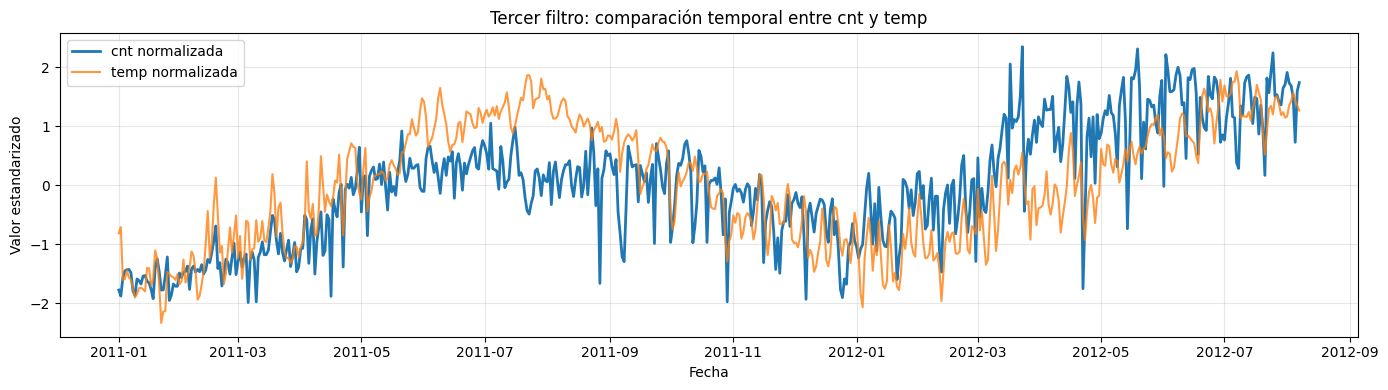

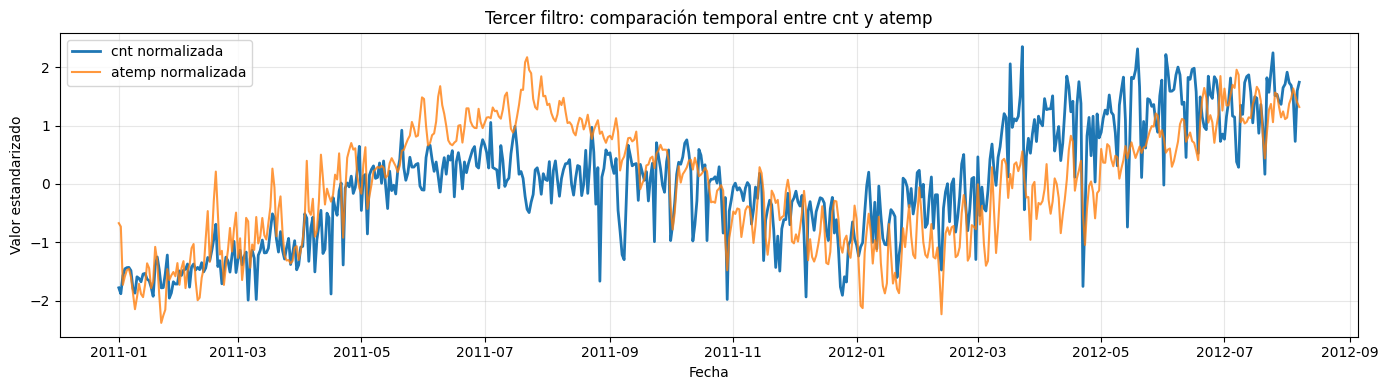

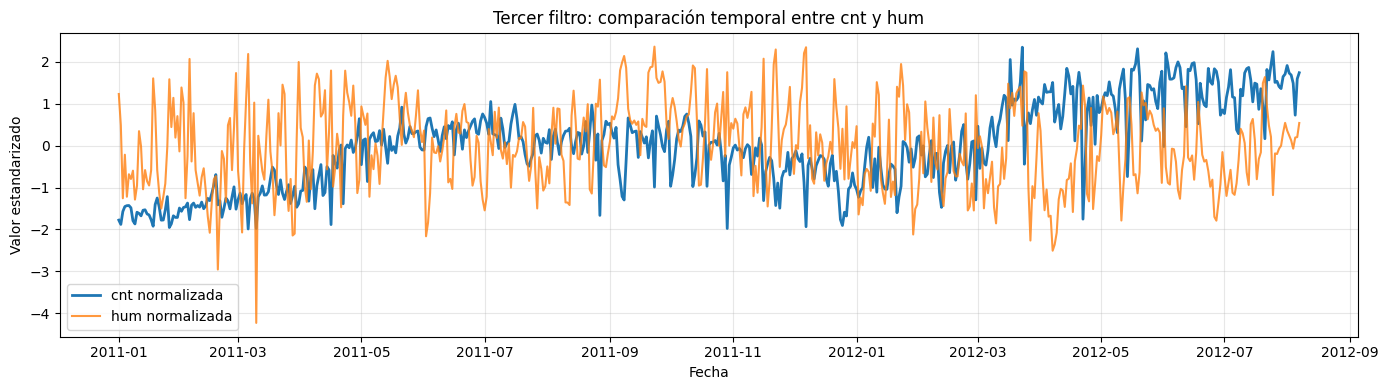

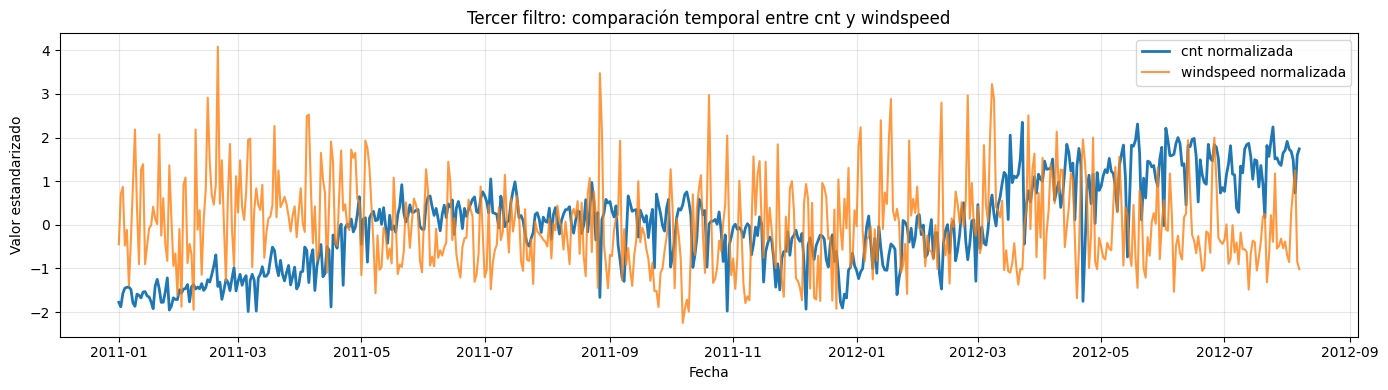

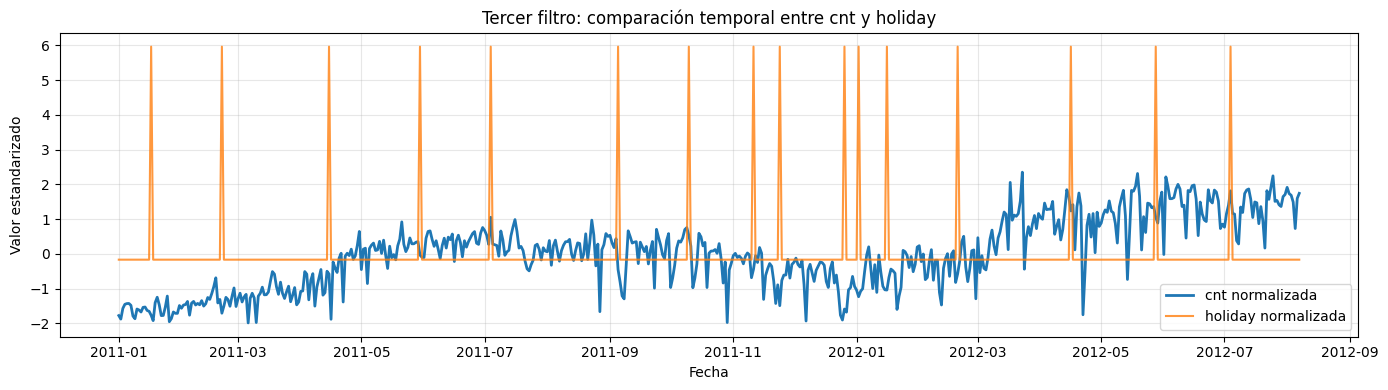

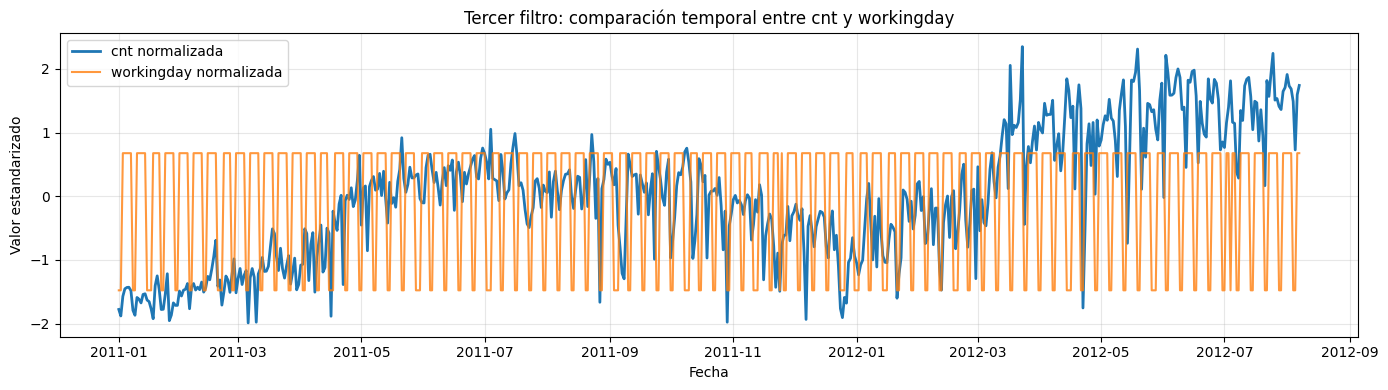

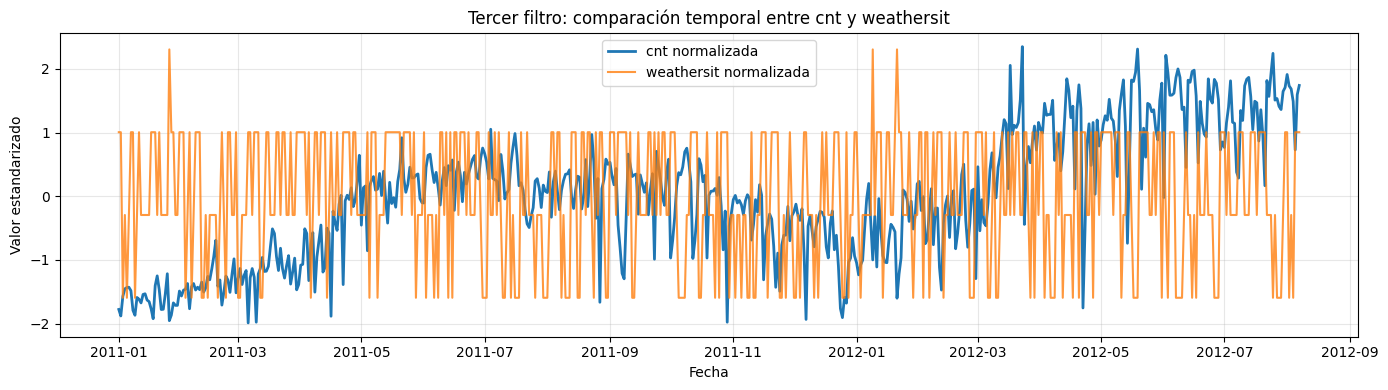

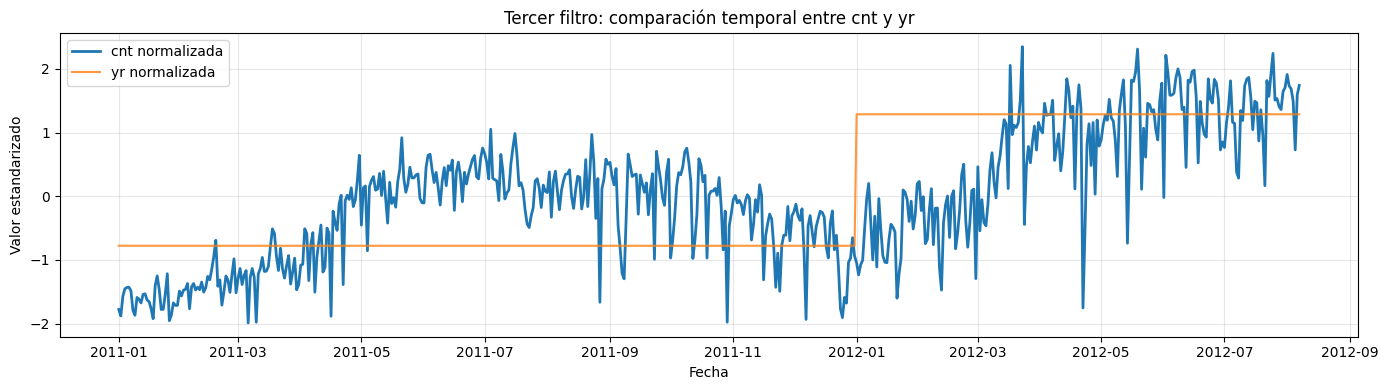

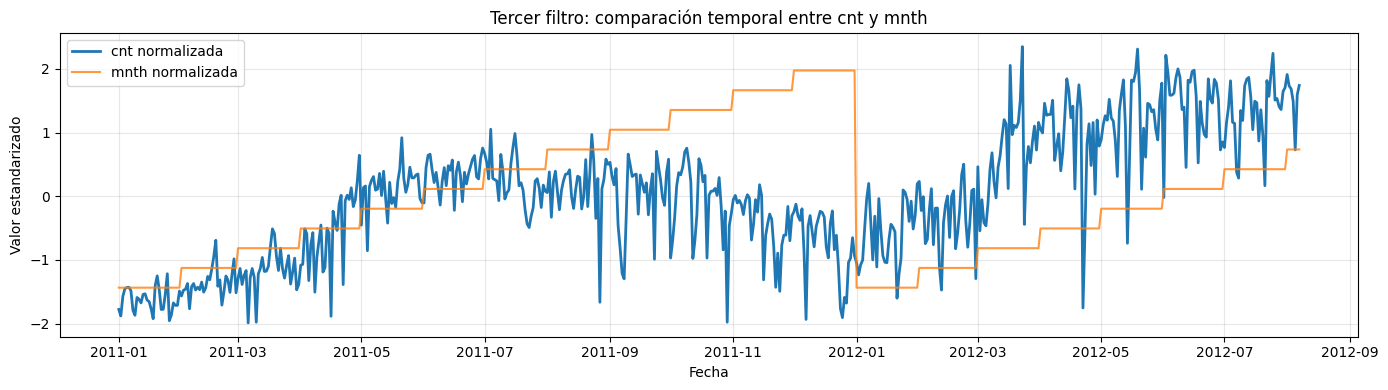

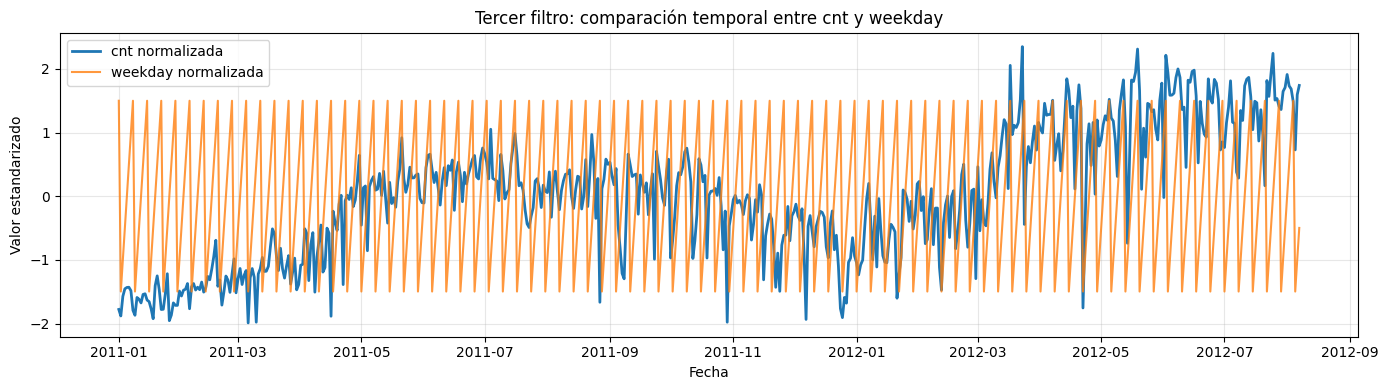

In [ ]:
from sklearn.preprocessing import StandardScaler

# Tomamos las variables exógenas disponibles en train.
variables_visualizar = exog_train_disponibles.columns.tolist()

# Construimos una tabla auxiliar con la variable objetivo y las exógenas.
# Esta tabla se usa solo para visualización.
datos_visual = pd.concat(
    [
        y_train.rename("cnt"),
        exog_train_disponibles[variables_visualizar]
    ],
    axis=1
)

# Creamos el escalador estándar.
# StandardScaler transforma cada variable para que tenga media 0 y desvío estándar 1.
scaler = StandardScaler()

# Ajustamos y transformamos usando solo datos de train.
datos_visual_norm = pd.DataFrame(
    scaler.fit_transform(datos_visual),
    columns=datos_visual.columns,
    index=datos_visual.index
)

# Graficamos cnt junto con cada variable exógena normalizada.
for variable in variables_visualizar:
    plt.figure(figsize=(14, 4))

    plt.plot(
        datos_visual_norm.index,
        datos_visual_norm["cnt"],
        label="cnt normalizada",
        linewidth=2
    )

    plt.plot(
        datos_visual_norm.index,
        datos_visual_norm[variable],
        label=f"{variable} normalizada",
        alpha=0.8
    )

    plt.title(f"Tercer filtro: comparación temporal entre cnt y {variable}")
    plt.xlabel("Fecha")
    plt.ylabel("Valor estandarizado")

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Decisión del tercer filtro: exploración visual

A partir de la exploración visual usando solo `train`, decidimos quitar la variable `holiday`.

Aunque `holiday` podría tener sentido desde el punto de vista del problema, en este ejemplo aparece como una variable muy puntual y no muestra una relación temporal clara con la demanda diaria de bicicletas.

Como el objetivo del notebook es construir un flujo didáctico y simple de selección de variables exógenas, dejamos fuera `holiday` en esta etapa.

El resto de variables se mantiene para continuar con los siguientes filtros.

In [ ]:
# Quitamos la variable holiday después de la exploración visual.
# Esta decisión se toma usando solo información de train.
exog_train_post_visual = exog_train_disponibles.drop(columns=["holiday"])
exog_test_post_visual = exog_test_disponibles.drop(columns=["holiday"])

# Verificamos las variables que continúan después del filtro visual.
print("Variables que continúan después del filtro visual:")
print(exog_train_post_visual.columns.tolist())

# Mostramos las primeras filas.
exog_train_post_visual.head()

Variables que continúan después del filtro visual:
['temp', 'atemp', 'hum', 'windspeed', 'workingday', 'weathersit', 'yr', 'mnth', 'weekday']


,temp,atemp,hum,windspeed,workingday,weathersit,yr,mnth,weekday
fecha,,,,,,,,,
2011-01-01,0.344167,0.363625,0.805833,0.160446,0,3.0,0,1,6
2011-01-02,0.363478,0.353739,0.696087,0.248539,0,3.0,0,1,0
2011-01-03,0.195000,0.186250,0.438750,0.261200,1,1.0,0,1,1
2011-01-04,0.197500,0.210227,0.592083,0.158281,1,2.0,0,1,2
2011-01-05,0.225833,0.228556,0.444167,0.185644,1,1.0,0,1,3


## Cuarto filtro: correlaciones y redundancia entre variables

Ahora vamos a analizar la matriz de correlaciones usando solamente datos de entrenamiento.

Incluimos la variable objetivo `cnt` y las variables exógenas que sobrevivieron a los filtros anteriores.

Esta matriz nos permite observar dos aspectos:

- la relación de cada variable exógena con la variable objetivo;
- la posible redundancia entre variables exógenas.

Una correlación alta con `cnt` puede indicar que una variable podría aportar información al modelo.  
Una correlación alta entre dos variables exógenas puede indicar que ambas contienen información muy parecida.

Este análisis sigue siendo exploratorio. No decide automáticamente qué variables conservar, pero ayuda a orientar la selección.

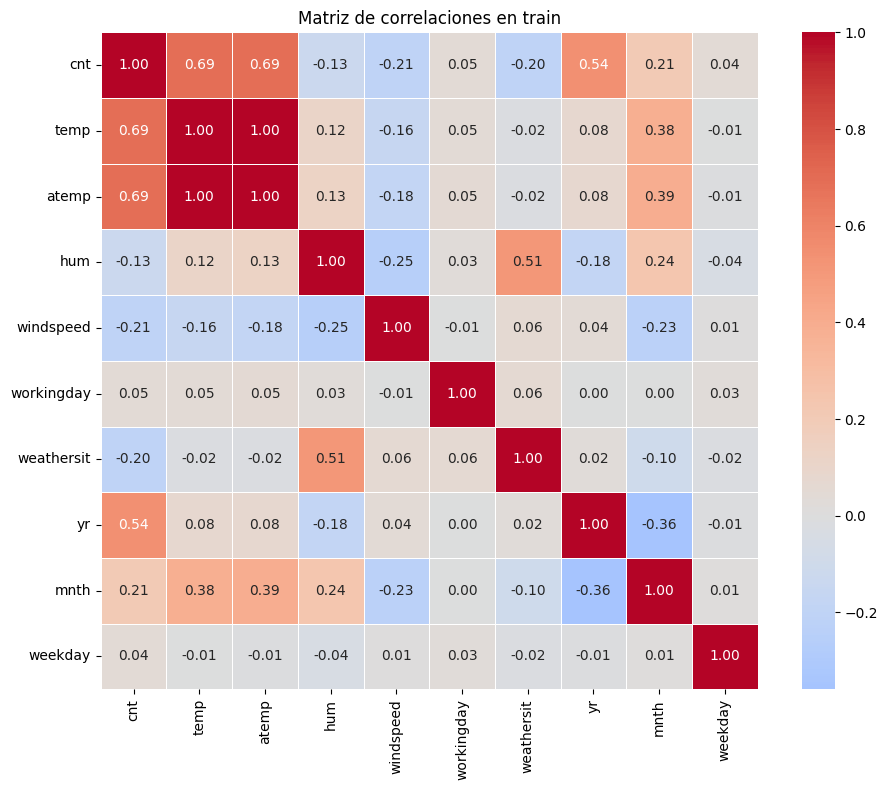

In [ ]:
import seaborn as sns

# Construimos una tabla auxiliar usando solo train.
# Incluimos la variable objetivo y las exógenas que quedaron luego del filtro visual.
datos_corr = pd.concat(
    [
        y_train.rename("cnt"),
        exog_train_post_visual
    ],
    axis=1
)

# Calculamos la matriz de correlaciones.
matriz_corr = datos_corr.corr(numeric_only=True)

# Graficamos la matriz de correlaciones.
plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Matriz de correlaciones en train")
plt.tight_layout()
plt.show()

## Decisión del cuarto filtro: correlación y redundancia

A partir de la matriz de correlaciones observamos que `temp` y `atemp` están altamente correlacionadas entre sí.

Además, ambas presentan prácticamente la misma correlación con la variable objetivo `cnt`.

Para simplificar el modelo y evitar variables redundantes, decidimos conservar `temp` y quitar `atemp`.

Aunque variables como `weekday` y `workingday` muestran baja correlación lineal con `cnt`, no se eliminan en esta etapa. En análisis anteriores observamos que existen patrones asociados al calendario, por lo que estas variables podrían aportar información útil al modelo.

Después de este filtro, continuamos con las variables restantes.

In [ ]:
# Quitamos atemp por redundancia con temp.
# Ambas variables están altamente correlacionadas entre sí y tienen una relación similar con cnt.
exog_train_post_corr = exog_train_post_visual.drop(columns=["atemp"])
exog_test_post_corr = exog_test_post_visual.drop(columns=["atemp"])

# Verificamos las variables que continúan después del filtro de correlación y redundancia.
print("Variables que continúan después del filtro de correlación y redundancia:")
print(exog_train_post_corr.columns.tolist())

# Mostramos las primeras filas.
exog_train_post_corr.head()

Variables que continúan después del filtro de correlación y redundancia:
['temp', 'hum', 'windspeed', 'workingday', 'weathersit', 'yr', 'mnth', 'weekday']


,temp,hum,windspeed,workingday,weathersit,yr,mnth,weekday
fecha,,,,,,,,
2011-01-01,0.344167,0.805833,0.160446,0,3.0,0,1,6
2011-01-02,0.363478,0.696087,0.248539,0,3.0,0,1,0
2011-01-03,0.195000,0.438750,0.261200,1,1.0,0,1,1
2011-01-04,0.197500,0.592083,0.158281,1,2.0,0,1,2
2011-01-05,0.225833,0.444167,0.185644,1,1.0,0,1,3


## Modelo multivariante base en train

Ahora vamos a construir un primer modelo multivariante.

La idea es tomar como punto de partida la mejor configuración encontrada en el modelo univariante y agregarle las variables exógenas seleccionadas.

Usaremos el mismo regresor y los mismos hiperparámetros del mejor modelo univariante anterior:

- `RandomForestRegressor`;
- `max_depth=10`;
- `n_estimators=200`;
- `random_state=42`.

También usaremos `lags=6`, lo que significa que el modelo tomará como entrada los valores de demanda de los últimos 6 días.

Esto no quiere decir que el modelo entrene solamente con 6 días, sino que cada observación de entrenamiento se construye usando los 6 valores anteriores de la serie.

En este caso, el modelo usará dos fuentes de información:

- los últimos valores observados de la serie `cnt`;
- las variables exógenas seleccionadas en la etapa anterior.

Como variables exógenas usaremos `exog_train_post_corr`, que contiene las variables seleccionadas luego del análisis visual, de correlación y de redundancia.

La evaluación se realizará con backtesting interno dentro de `train`, usando el mismo esquema de validación temporal utilizado en la etapa univariante.

El conjunto `test` todavía no se usa.

In [ ]:
# Creamos el modelo multivariante base.
# Usamos la mejor configuración encontrada en el modelo univariante:
# RandomForestRegressor con max_depth=10, n_estimators=200 y lags=6.
forecaster_multi_base = ForecasterRecursive(
    estimator=RandomForestRegressor(
        random_state=42,
        max_depth=10,
        n_estimators=200
    ),
    lags=6
)

forecaster_multi_base

=================== 
ForecasterRecursive 
=================== 
Estimator: RandomForestRegressor 
Lags: [1 2 3 4 5 6] 
Window features: None 
Window size: 6 
Series name: None 
Exogenous included: False 
Exogenous names: None 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: None 
Training index type: None 
Training index frequency: None 
Estimator parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    10, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200,
    'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2026-06-15 01:44:53 
Last fit date: None 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

In [ ]:
# Evaluamos el modelo multivariante base con backtesting interno en train.
# En este caso agregamos las variables exógenas seleccionadas.
metrica_multi_base, predicciones_multi_base = backtesting_forecaster(
    forecaster=forecaster_multi_base,
    y=y_train,
    exog=exog_train_post_corr,
    cv=cv,
    metric="mean_absolute_error",
    verbose=False,
    show_progress=True
)

metrica_multi_base

  0%|          | 0/26 [00:00<?, ?it/s]

,mean_absolute_error
0,858.551166


In [ ]:
# Mostramos las primeras predicciones generadas por el backtesting.
predicciones_multi_base.head()

,fold,pred
2012-02-14,0,3733.853296
2012-02-15,0,4030.882185
2012-02-16,0,3134.952368
2012-02-17,0,2997.135574
2012-02-18,0,2706.596243


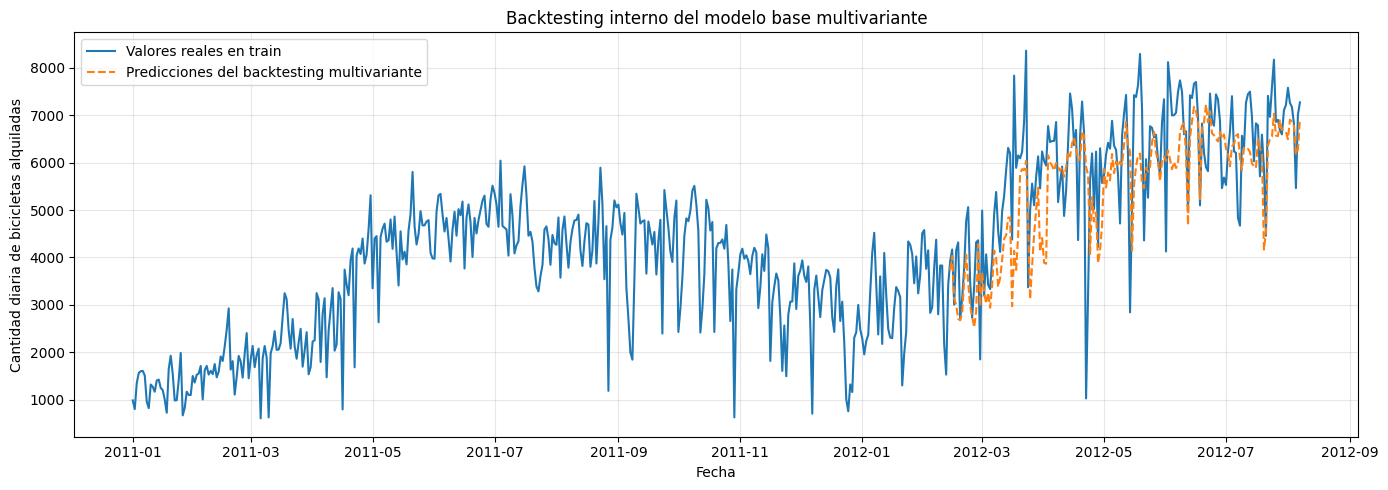

In [ ]:
# Graficamos la serie real completa de entrenamiento
# junto con las predicciones generadas por el backtesting interno multivariante.
plt.figure(figsize=(14, 5))

plt.plot(
    y_train.index,
    y_train,
    label="Valores reales en train"
)

plt.plot(
    predicciones_multi_base.index,
    predicciones_multi_base["pred"],
    label="Predicciones del backtesting multivariante",
    linestyle="--"
)

plt.title("Backtesting interno del modelo base multivariante")
plt.xlabel("Fecha")
plt.ylabel("Cantidad diaria de bicicletas alquiladas")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
mae_base_univariante = metrica_base["mean_absolute_error"].iloc[0]
mae_ajustado_univariante = resultados_grid.iloc[0]["mean_absolute_error"]
mae_base_multivariante = metrica_multi_base["mean_absolute_error"].iloc[0]

comparacion_train = pd.DataFrame({
    "Modelo": [
        "Base univariante",
        "Ajustado univariante",
        "Base multivariante"
    ],
    "MAE validación interna en train": [
        mae_base_univariante,
        mae_ajustado_univariante,
        mae_base_multivariante
    ]
})

comparacion_train["MAE validación interna en train"] = (
    comparacion_train["MAE validación interna en train"].round(2)
)

comparacion_train

,Modelo,MAE validación interna en train
0,Base univariante,1016.73
1,Ajustado univariante,962.35
2,Base multivariante,858.55


El modelo multivariante base mejora claramente el desempeño del modelo univariante ajustado durante la validación interna en train.

Esto indica que las variables exógenas seleccionadas aportan información adicional a los lags de la serie.

Sin embargo, esta mejora todavía corresponde a validación interna dentro de train. La conclusión final deberá confirmarse más adelante con la evaluación sobre test.

## Grid Search multivariante en train

Después de evaluar el modelo multivariante base, vamos a realizar una búsqueda de mejores lags e hiperparámetros.

El procedimiento es el mismo que usamos en el modelo univariante, pero ahora incorporamos las variables exógenas seleccionadas.

La búsqueda se realiza solamente dentro de `train`, usando:

- `y_train` como variable objetivo;
- `exog_train_post_corr` como variables exógenas;
- el mismo esquema de validación temporal interna `cv`;
- la misma métrica de evaluación.

El conjunto `test` todavía no se usa.

El objetivo es encontrar la mejor configuración multivariante antes de hacer la evaluación final.

In [ ]:
# Ejecutamos el Grid Search multivariante dentro de train.
# Usamos el forecaster multivariante base ya creado.
# El Grid Search probará distintas combinaciones de lags e hiperparámetros,
# incorporando las variables exógenas seleccionadas.

resultados_grid_multi = grid_search_forecaster(
    forecaster=forecaster_multi_base,
    y=y_train,
    exog=exog_train_post_corr,
    cv=cv,
    lags_grid=lags_grid,
    param_grid=param_grid,
    metric="mean_absolute_error",
    return_best=True,
    verbose=False,
    show_progress=True
)

resultados_grid_multi.head()

lags grid:   0%|          | 0/9 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

...

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

,lags,lags_label,params,mean_absolute_error,max_depth,n_estimators
0,"[1, 2, 3, 4, 5, 6]","[1, 2, 3, 4, 5, 6]","{'max_depth': None, 'n_estimators': 100}",849.330114,NaN,100.0
1,"[1, 2, 3, 4, 5, 6]","[1, 2, 3, 4, 5, 6]","{'max_depth': 10, 'n_estimators': 100}",852.752120,10.0,100.0
2,"[1, 2, 3, 4, 5, 6]","[1, 2, 3, 4, 5, 6]","{'max_depth': None, 'n_estimators': 200}",853.806534,NaN,200.0
3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]","{'max_depth': 10, 'n_estimators': 100}",855.603276,10.0,100.0
4,"[1, 2, 3, 4]","[1, 2, 3, 4]","{'max_depth': None, 'n_estimators': 100}",856.290227,NaN,100.0


## Mejor configuración encontrada

Ahora vamos a extraer solamente la mejor configuración encontrada por el Grid Search.

La tabla `resultados_grid_multi` está ordenada según la métrica principal utilizada en la búsqueda.  
Por eso, la primera fila corresponde a la configuración con menor MAE dentro de la validación temporal interna.

Esta selección fue realizada usando `y_train`, no el conjunto `test`.

In [ ]:
# Extraemos la primera fila de resultados_grid.
# Esa fila corresponde a la mejor configuración según la métrica principal.
mejor_configuracion = resultados_grid_multi.iloc[0]

print("Mejor configuración encontrada")
print("--------------------------------")
print("Lags seleccionados:")
print(mejor_configuracion["lags"])

print("\nHiperparámetros seleccionados:")
print(mejor_configuracion["params"])

print("\nMAE en validación temporal interna:")
print(round(mejor_configuracion["mean_absolute_error"], 2))

Mejor configuración encontrada
--------------------------------
Lags seleccionados:
[1 2 3 4 5 6]

Hiperparámetros seleccionados:
{'max_depth': None, 'n_estimators': 100}

MAE en validación temporal interna:
849.33


## Visualización del modelo multivariante ajustado

El Grid Search multivariante ya seleccionó la mejor combinación de lags e hiperparámetros usando validación temporal interna sobre `y_train`.

Como usamos `return_best=True`, el objeto `forecaster_multi_base` quedó actualizado con esa mejor configuración.

Ahora ejecutamos nuevamente el backtesting interno solamente para obtener las predicciones del modelo multivariante ajustado y poder visualizarlas.

Este paso no realiza una nueva selección de modelo.  
Solo permite graficar el comportamiento del mejor modelo multivariante dentro de `train`.

El conjunto `test` todavía no se usa.

In [ ]:
# Ejecutamos nuevamente el backtesting interno solo para obtener
# las predicciones del modelo multivariante ajustado.
# El modelo ya fue seleccionado previamente por el Grid Search.

metrica_multi_ajustado, predicciones_multi_ajustado = backtesting_forecaster(
    forecaster=forecaster_multi_base,
    y=y_train,
    exog=exog_train_post_corr,
    cv=cv,
    metric="mean_absolute_error",
    verbose=False,
    show_progress=True
)

metrica_multi_ajustado

  0%|          | 0/26 [00:00<?, ?it/s]

,mean_absolute_error
0,849.330114


In [ ]:
# Mostramos las primeras predicciones generadas por el backtesting interno
# del modelo multivariante ajustado.

predicciones_multi_ajustado.head()

,fold,pred
2012-02-14,0,3748.43
2012-02-15,0,4081.70
2012-02-16,0,3169.67
2012-02-17,0,3015.54
2012-02-18,0,2626.22


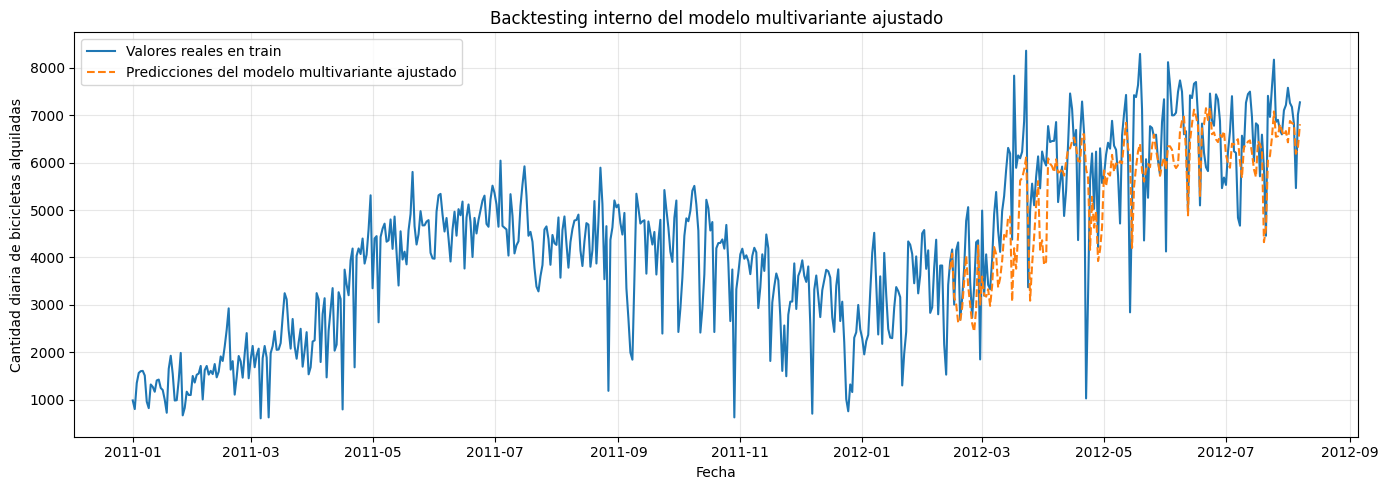

In [ ]:
# Graficamos la serie real de entrenamiento junto con las predicciones
# generadas por el modelo multivariante ajustado durante el backtesting interno.

plt.figure(figsize=(14, 5))

plt.plot(
    y_train.index,
    y_train,
    label="Valores reales en train"
)

plt.plot(
    predicciones_multi_ajustado.index,
    predicciones_multi_ajustado["pred"],
    label="Predicciones del modelo multivariante ajustado",
    linestyle="--"
)

plt.title("Backtesting interno del modelo multivariante ajustado")
plt.xlabel("Fecha")
plt.ylabel("Cantidad diaria de bicicletas alquiladas")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluación final en test del modelo multivariante ajustado

Después de seleccionar el mejor modelo multivariante usando solamente validación interna en `train`, realizamos la evaluación final sobre `test`.

En esta etapa el modelo ya está fijo.

No se vuelven a seleccionar variables, lags ni hiperparámetros.

Para respetar el mismo protocolo usado en la evaluación final del modelo univariante, concatenamos `y_train` e `y_test`, y también concatenamos las variables exógenas de train y test.

El backtesting final comienza después de `y_train`, por lo que las predicciones evaluadas corresponden al período de `test`.

In [ ]:
# Construimos la serie completa para la evaluación final.
y_total = pd.concat([y_train, y_test])

# Construimos las variables exógenas completas, alineadas con y_total.
exog_total = pd.concat([exog_train_post_corr, exog_test_post_corr])

In [ ]:
# Evaluamos el mejor modelo multivariante sobre test.
# Usamos el mismo cv_test definido para la evaluación final del modelo univariante.

metrica_multi_test, predicciones_multi_test = backtesting_forecaster(
    forecaster=forecaster_multi_base,
    y=y_total,
    exog=exog_total,
    cv=cv_test,
    metric="mean_absolute_error",
    verbose=False,
    show_progress=True
)

metrica_multi_test

  0%|          | 0/21 [00:00<?, ?it/s]

,mean_absolute_error
0,924.901096


In [ ]:
# Mostramos las primeras predicciones generadas en test.
predicciones_multi_test.head()

,fold,pred
2012-08-08,0,7309.97
2012-08-09,0,7157.55
2012-08-10,0,6893.39
2012-08-11,0,6197.15
2012-08-12,0,6567.80


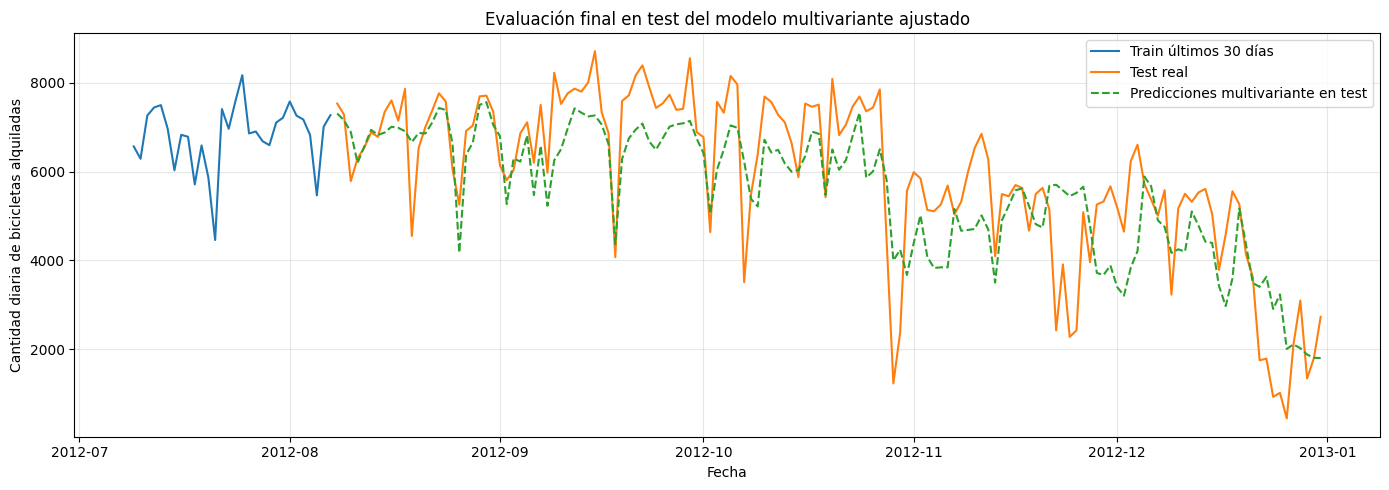

In [ ]:
# Graficamos los valores reales de test junto con las predicciones
# del modelo multivariante ajustado.

dias_contexto = 30
train_contexto = y_train.iloc[-dias_contexto:]

plt.figure(figsize=(14, 5))

plt.plot(
    train_contexto.index,
    train_contexto,
    label="Train últimos 30 días"
)

plt.plot(
    y_test.index,
    y_test,
    label="Test real"
)

plt.plot(
    predicciones_multi_test.index,
    predicciones_multi_test["pred"],
    label="Predicciones multivariante en test",
    linestyle="--"
)

plt.title("Evaluación final en test del modelo multivariante ajustado")
plt.xlabel("Fecha")
plt.ylabel("Cantidad diaria de bicicletas alquiladas")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Comparación final de modelos

Ahora comparamos el mejor modelo univariante con el mejor modelo multivariante.

Ambos modelos fueron seleccionados usando validación temporal interna dentro de `train`.

Luego, ambos fueron evaluados sobre el mismo conjunto `test`, usando el mismo horizonte, la misma métrica y el mismo protocolo de evaluación final.

Esta comparación permite analizar si las variables exógenas seleccionadas realmente mejoraron el desempeño del modelo.

In [ ]:
# Extraemos las métricas principales de los modelos ajustados.

mae_univariante_train = resultados_grid.iloc[0]["mean_absolute_error"]
mae_univariante_test = metrica_test["mean_absolute_error"].iloc[0]

mae_multivariante_train = resultados_grid_multi.iloc[0]["mean_absolute_error"]
mae_multivariante_test = metrica_multi_test["mean_absolute_error"].iloc[0]

# Construimos la tabla comparativa final.
comparacion_final_modelos = pd.DataFrame({
    "Modelo": [
        "Mejor univariante",
        "Mejor multivariante"
    ],
    "MAE validación interna en train": [
        mae_univariante_train,
        mae_multivariante_train
    ],
    "MAE evaluación final en test": [
        mae_univariante_test,
        mae_multivariante_test
    ]
})

comparacion_final_modelos = comparacion_final_modelos.round(2)

comparacion_final_modelos

,Modelo,MAE validación interna en train,MAE evaluación final en test
0,Mejor univariante,962.35,1155.88
1,Mejor multivariante,849.33,924.90


## Interpretación final

La comparación muestra que el modelo multivariante obtiene un menor MAE que el modelo univariante tanto en la validación interna dentro de `train` como en la evaluación final sobre `test`.

En validación interna, el MAE baja de 962.35 a 849.33.  
En test, el MAE baja de 1155.88 a 924.90.

Esto indica que las variables exógenas seleccionadas aportaron información relevante para mejorar el pronóstico de la demanda diaria de bicicletas.

La mejora en `test` es especialmente importante, porque confirma que el modelo multivariante no solo mejoró durante la validación interna, sino que también generalizó mejor sobre datos no usados durante la selección

## Importancia de variables en el modelo multivariante

Una vez seleccionado y evaluado el mejor modelo multivariante, podemos analizar qué variables fueron más relevantes para el regresor.

Como el modelo usa un `RandomForestRegressor`, podemos obtener la importancia de las variables utilizadas durante el entrenamiento.

En este caso, las variables del modelo incluyen tanto los lags de la serie objetivo como las variables exógenas seleccionadas.

Esta importancia debe interpretarse como una medida interna del modelo, no como una relación causal.

In [113]:
# Reajustamos el mejor modelo multivariante sobre train.
# Esto no cambia la selección del modelo: solo deja el modelo entrenado
# para poder inspeccionar la importancia de sus variables.

forecaster_multi_base.fit(
    y=y_train,
    exog=exog_train_post_corr
)

# Obtenemos la importancia de las variables utilizadas por el modelo.
importancias_multi = forecaster_multi_base.get_feature_importances(
    sort_importance=True
)

importancias_multi

,feature,importance
0,lag_1,0.608778
6,temp,0.071875
5,lag_6,0.063748
7,hum,0.051163
3,lag_4,0.035801
1,lag_2,0.032427
4,lag_5,0.030705
11,yr,0.027878
2,lag_3,0.025841
10,weathersit,0.020248


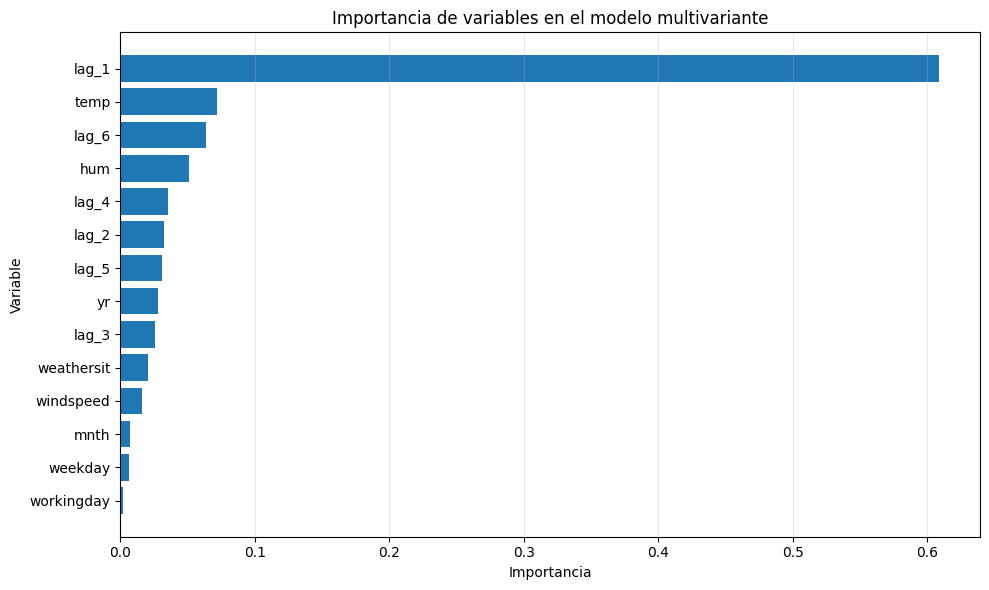

In [114]:
# Graficamos la importancia de variables del modelo multivariante.

plt.figure(figsize=(10, 6))

plt.barh(
    importancias_multi["feature"],
    importancias_multi["importance"]
)

plt.title("Importancia de variables en el modelo multivariante")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()